In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Car details v3.csv"

# Load the latest version
data = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "nehalbirla/vehicle-dataset-from-cardekho",
  file_path,
 ) 

C:\Users\Marqu\MachineLearning\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Marqu\AppData\Local\Temp\ipykernel_31940\474411827.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  data = kagglehub.load_dataset(


O vehicle-dataset do Kaggle possui 4 datasets em sua base, escolhemos o dataset "Car details v3" por se encaixar melhor na proposta do projeto e conter conteúdo suficiente para uma anáise exploratória consistente. Ao que se observa em uma visualização comparativa com os outros 3. 

Alguns critérios do enunciado voltados à classificação não se aplicam diretamente, como desbalanceamento de classes e separabilidade entre classes, nesses casos, analisaremos a distribuição do target e padrões associados ao preço

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
print(data.shape)  #Para vermos numero de linhas e colunas
data.info()

(8128, 13)
<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


O dataset selecionado contém 8128 linhas ou registros e 13 váriaveis ou colunas. A análise inicial permite que indentifiquemos o target "selling_price" e visualizar a estrutura geral das features dispíveis. Nas próximas etapas, vamos analisar cada variável quanto ao significado, tipo e qualidade dos dados.

TARGET -> selling_price

Dicionário das variáveis:

| Variável        | Significado                                                                   | Tipo conceitual                                              | Papel      |
| --------------- | ----------------------------------------------------------------------------- | ------------------------------------------------------------ | ---------- |
| `name`          | Nome/modelo do veículo, incluindo normalmente marca e versão                  | Categórica nominal                                           | Feature    |
| `year`          | Ano de fabricação/registro do veículo                                         | Numérica discreta/temporal                                   | Feature    |
| `selling_price` | Preço de venda registrado para o veículo                                      | Numérica                                                     | **Target** |
| `km_driven`     | Quilometragem já percorrida pelo veículo                                      | Numérica                                                     | Feature    |
| `fuel`          | Tipo de combustível utilizado pelo veículo                                    | Categórica nominal                                           | Feature    |
| `seller_type`   | Tipo de vendedor responsável pelo anúncio/venda                               | Categórica nominal                                           | Feature    |
| `transmission`  | Tipo de transmissão do veículo                                                | Categórica nominal                                           | Feature    |
| `owner`         | Indica a ordem do proprietário atual, como primeiro, segundo ou terceiro dono | Categórica ordinal                                           | Feature    |
| `mileage`       | Eficiência/consumo de combustível do veículo                                  | Numérica contínua conceitualmente                            | Feature    |
| `engine`        | Capacidade/cilindrada do motor, apresentada em `CC`                           | Numérica conceitualmente                                     | Feature    |
| `max_power`     | Potência máxima do motor, geralmente apresentada em `bhp`                     | Numérica contínua conceitualmente                            | Feature    |
| `torque`        | Torque do motor e, em muitos registros, a rotação em que ele é atingido       | Numérica conceitualmente, mas representada de forma composta | Feature    |
| `seats`         | Quantidade de assentos do veículo                                             | Numérica discreta                                            | Feature    |


A variável selling_price foi definida como target do projeto, caracterizando a futura tarefa como um problema de regressão. As outras variáveis serão inicialmente consideradas features candidatas. Algumas variáveis que representam grandezas numéricas aparecem armazenadas como texto, o data.info() retorna elas como object, aspecto que será investigado mais a frente durante a análise de qualidade e pré-processamento. Contudo, parecem ser referentes as ordens de grandeza ou unidade de medida

In [5]:
data.isna().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

Valores ausentes em cinco variáveis: mileage, engine, max_power, torque e seats

In [6]:
data.duplicated().sum()

np.int64(1202)

1202 linhas idênticas

In [7]:
data.nunique().sort_values() #Quantos valores diferentes existem em cada coluna.

transmission        2
seller_type         3
fuel                4
owner               5
seats               9
year               29
engine            121
max_power         322
mileage           393
torque            441
selling_price     677
km_driven         921
name             2058
dtype: int64

name tem 2058 valores diferentes, alta cardinalidade. É algo importante de se notar.

Vamos investigar esses aspectos após essa análise de qualidade dos dados, antes de definir estratégias de pré-processamento

Ainda não vamos usar drop duplicates pois em um dataset de carros duas linhas iguais podem significar duas coisas diferentes. Ou um mesmo anúncio repetido, ou dois carros diferentes mas com exatamente as mesmas características registradas.

Vamos verificar quais valores estão nas variáveis categóricas:

In [8]:
categorical_columns = [
    
    "fuel",
    "seller_type",
    "transmission",
    "owner",
]

for column in categorical_columns:
    print(f"\n {column}: ")
    print(data[column].value_counts(dropna=False))
    #print(data[column].astype(str).str.strip().unique) verificação de espaços


 fuel: 
fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

 seller_type: 
seller_type
Individual          6766
Dealer              1126
Trustmark Dealer     236
Name: count, dtype: int64

 transmission: 
transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64

 owner: 
owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64


A inspeção das variáveis categóricas não revelou inconsistências aparentes de nomenclatura, como diferenças de capitalização, erros de escrita ou categorias duplicadas semanticamente. Dessa forma, não foi identificado neste momento um tratamento de padronização necessário para essas variáveis.

Vamos voltar e fechar a análise das variáveus que conceitualmente são númericas mas o pandas retornou como object

In [9]:
numeric_as_text = ["mileage", "engine", "max_power", "torque"]

for column in numeric_as_text:
    print(f"\n{column}: ")
    print(data[column].dropna().drop_duplicates().head(15).to_list())


mileage: 
['23.4 kmpl', '21.14 kmpl', '17.7 kmpl', '23.0 kmpl', '16.1 kmpl', '20.14 kmpl', '17.3 km/kg', '23.59 kmpl', '20.0 kmpl', '19.01 kmpl', '17.3 kmpl', '19.3 kmpl', '18.9 kmpl', '18.15 kmpl', '24.52 kmpl']

engine: 
['1248 CC', '1498 CC', '1497 CC', '1396 CC', '1298 CC', '1197 CC', '1061 CC', '796 CC', '1364 CC', '1399 CC', '1461 CC', '993 CC', '1198 CC', '1199 CC', '998 CC']

max_power: 
['74 bhp', '103.52 bhp', '78 bhp', '90 bhp', '88.2 bhp', '81.86 bhp', '57.5 bhp', '37 bhp', '67.1 bhp', '68.1 bhp', '108.45 bhp', '60 bhp', '73.9 bhp', '67 bhp', '82 bhp']

torque: 
['190Nm@ 2000rpm', '250Nm@ 1500-2500rpm', '12.7@ 2,700(kgm@ rpm)', '22.4 kgm at 1750-2750rpm', '11.5@ 4,500(kgm@ rpm)', '113.75nm@ 4000rpm', '7.8@ 4,500(kgm@ rpm)', '59Nm@ 2500rpm', '170Nm@ 1800-2400rpm', '160Nm@ 2000rpm', '248Nm@ 2250rpm', '78Nm@ 4500rpm', '84Nm@ 3500rpm', '115Nm@ 3500-3600rpm', '200Nm@ 1750rpm']


engine -> número + CC

max_power -> número + bhp
(Contudo, há anomalias. Há alguns registros com 0 e valor contendo somente bhp)

mileage -> 2 unidades diferentes -> km/l e km/kg

torque -> Nm, kgm, rpm, intervalos de rotação...
(várias formas diferentes de escrever a mesma informção)

A inspeção revelou que mileage, engine, max_power e torque, apesar de representarem grandezas numéricas, estão armazenadas como texto devido à presença de unidades e outras informações nos valores.

Essas características deverão ser consideradas posteriormente na definição das estratégias de transformação e pré-processamento.

## 1. Investigação e decisão sobre duplicatas

Retomando o ponto das 1202 linhas idênticas. Antes de decidir, vamos ver como essas duplicatas se organizam: quantas linhas estão envolvidas e se aparecem em pares ou em grupos maiores.

In [10]:
all_columns = list(data.columns)
duplicated_any = data.duplicated(keep=False)

print(f"Linhas que possuem pelo menos uma cópia idêntica: {duplicated_any.sum()}")
print(f"Cópias extras (além da primeira ocorrência): {data.duplicated().sum()}")

duplicate_group_sizes = data[duplicated_any].groupby(all_columns, dropna=False).size()
print("\nTamanho do grupo de linhas idênticas -> quantidade de grupos:")
print(duplicate_group_sizes.value_counts().sort_index())

Linhas que possuem pelo menos uma cópia idêntica: 1827
Cópias extras (além da primeira ocorrência): 1202

Tamanho do grupo de linhas idênticas -> quantidade de grupos:
2     577
3      21
4       4
5       1
6       2
12      1
18      1
29      7
30      5
31      2
32      2
34      2
Name: count, dtype: int64


In [11]:
data[duplicated_any].sort_values(["name", "year", "km_driven"]).head(6)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
1977,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73 kmpl,1968 CC,174.33 bhp,380Nm@ 1750-2500rpm,5.0
7324,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73 kmpl,1968 CC,174.33 bhp,380Nm@ 1750-2500rpm,5.0
2129,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22 kmpl,2967 CC,241.4 bhp,580Nm@ 1400-3250rpm,5.0
7775,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22 kmpl,2967 CC,241.4 bhp,580Nm@ 1400-3250rpm,5.0
131,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
1561,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0


As 1202 cópias extras estão espalhadas em 1827 linhas. A maioria aparece em pares (577 grupos com 2 linhas), mas também existem 18 grupos com 29 a 34 linhas exatamente iguais. Nos exemplos acima, até valores bem específicos como `km_driven = 76131` e o texto do torque coincidem.

O dataset não possui um identificador único de anúncio, então não conseguimos afirmar com certeza se cada duplicata é o mesmo anúncio repetido ou carros diferentes que têm exatamente os mesmos atributos registrados. Mesmo assim, coincidirem as 13 colunas ao mesmo tempo (incluindo quilometragem e preço exatos) é pouco provável para carros usados distintos, principalmente nos grupos com mais de 30 cópias.

O ponto decisivo é a avaliação futura do modelo: se essas linhas forem mantidas, cópias idênticas podem cair ao mesmo tempo no treino e no teste. O modelo seria avaliado em exemplos que ele já viu no treino, o que gera data leakage e uma avaliação otimista demais.

**Decisão:** vamos remover as duplicatas exatas (mantendo a primeira ocorrência) antes do train/test split. Veículos apenas parecidos, como o mesmo modelo com quilometragem, ano ou preço diferentes, **não** são tratados como duplicados.

In [12]:
rows_before = len(data)
data_clean = data.drop_duplicates().reset_index(drop=True)
rows_after = len(data_clean)

print(f"Linhas antes: {rows_before}")
print(f"Linhas removidas: {rows_before - rows_after}")
print(f"Linhas restantes: {rows_after}")

Linhas antes: 8128
Linhas removidas: 1202
Linhas restantes: 6926


## 2. Limpeza e feature engineering determinísticos

Agora vamos transformar `engine`, `max_power`, `mileage` e `torque` em features numéricas. Essas transformações são **determinísticas**: cada linha é convertida só olhando para o próprio texto, sem usar estatísticas do dataset (média, mediana etc.). Por isso podem ser feitas antes do train/test split sem gerar vazamento de informação.

Os missing values continuarão como `NaN`, pois a imputação será feita depois, dentro do pipeline e ajustada somente no treino.

Vamos criar duas funções auxiliares: uma que extrai o primeiro número de um texto e outra que mostra quantos valores foram convertidos e quantos falharam.

In [13]:
import re

NUMBER_PATTERN = re.compile(r"\d+(?:\.\d+)?")

def extract_first_number(text):
    # Retorna o primeiro número encontrado no texto, ou NaN se não existir
    if pd.isna(text):
        return np.nan
    match = NUMBER_PATTERN.search(str(text))
    return float(match.group()) if match else np.nan

def conversion_report(original, converted):
    # Compara a coluna textual original com a versão numérica
    failed_mask = original.notna() & converted.isna()
    print(f"Missing já existentes no original: {original.isna().sum()}")
    print(f"Convertidos com sucesso: {converted.notna().sum()}")
    print(f"Falhas de conversão (havia texto, mas sem número válido): {failed_mask.sum()}")
    if failed_mask.any():
        print("Valores que falharam:", original[failed_mask].unique().tolist())

### ENGINE

In [14]:
print("Unidades encontradas em engine:")
print(data_clean["engine"].str.extract(r"([A-Za-z]+)\s*$")[0].value_counts(dropna=False))
print()

data_clean["engine_cc"] = data_clean["engine"].apply(extract_first_number)
conversion_report(data_clean["engine"], data_clean["engine_cc"])
data_clean["engine_cc"].describe()

Unidades encontradas em engine:
0
CC     6718
NaN     208
Name: count, dtype: int64

Missing já existentes no original: 208
Convertidos com sucesso: 6718
Falhas de conversão (havia texto, mas sem número válido): 0


count    6718.000000
mean     1430.891337
std       493.493277
min       624.000000
25%      1197.000000
50%      1248.000000
75%      1498.000000
max      3604.000000
Name: engine_cc, dtype: float64

Todos os 6718 valores preenchidos de `engine` estão em `CC`, e todos foram convertidos (0 falhas). Os 208 missing continuam como NaN. A cilindrada vai de 624 CC a 3604 CC, com mediana de 1248 CC, valores coerentes para carros de passeio e utilitários. Como existe uma única unidade, basta guardar o número em `engine_cc`.

### MAX_POWER

In [15]:
print("Unidades encontradas em max_power:")
print(data_clean["max_power"].str.extract(r"([A-Za-z]+)\s*$")[0].value_counts(dropna=False))
print()

data_clean["max_power_bhp"] = data_clean["max_power"].apply(extract_first_number)
conversion_report(data_clean["max_power"], data_clean["max_power_bhp"])
data_clean["max_power_bhp"].describe()

Unidades encontradas em max_power:
0
bhp    6718
NaN     208
Name: count, dtype: int64

Missing já existentes no original: 205
Convertidos com sucesso: 6720
Falhas de conversão (havia texto, mas sem número válido): 1
Valores que falharam: [' bhp']


count    6720.000000
mean       87.726919
std        31.771619
min         0.000000
25%        67.100000
50%        81.830000
75%       100.000000
max       400.000000
Name: max_power_bhp, dtype: float64

Em `max_power`, 6720 valores foram convertidos e houve 1 falha: o texto `' bhp'`, que tem a unidade mas nenhum número. Na prática é um valor ausente, então ficou como NaN. As 2 linhas a mais convertidas em relação à contagem de `bhp` são registros com o texto `0` sem unidade, e por isso o mínimo aparece como 0 bhp, o que é fisicamente impossível para um carro. Vamos voltar a esse ponto na seção de outliers, já usando só o treino. A mediana é 81,83 bhp e o máximo 400 bhp.

### MILEAGE

Aqui não podemos simplesmente apagar a unidade: `kmpl` (quilômetros por litro) e `km/kg` (quilômetros por quilograma de gás) são grandezas diferentes. Vamos separar o valor e a unidade em duas colunas.

In [16]:
data_clean["mileage_unit"] = data_clean["mileage"].str.extract(r"(kmpl|km/kg)")[0]
data_clean["mileage_value"] = data_clean["mileage"].apply(extract_first_number)

print("Observações por unidade de mileage:")
print(data_clean["mileage_unit"].value_counts(dropna=False))
print(f"\nTexto presente mas unidade não reconhecida: {(data_clean['mileage'].notna() & data_clean['mileage_unit'].isna()).sum()}\n")
conversion_report(data_clean["mileage"], data_clean["mileage_value"])

pd.crosstab(data_clean["fuel"], data_clean["mileage_unit"], dropna=False)

Observações por unidade de mileage:
mileage_unit
kmpl     6631
NaN       208
km/kg      87
Name: count, dtype: int64

Texto presente mas unidade não reconhecida: 0

Missing já existentes no original: 208
Convertidos com sucesso: 6718
Falhas de conversão (havia texto, mas sem número válido): 0


mileage_unit,km/kg,kmpl,NaN
fuel,,,
CNG,52,0,4
Diesel,0,3658,97
LPG,35,0,3
Petrol,0,2973,104


Das 6718 observações preenchidas, 6631 estão em `kmpl` e 87 em `km/kg`. O crosstab mostra que `km/kg` aparece **somente** em carros CNG (52) e LPG (35), enquanto Diesel e Petrol usam apenas `kmpl`. Ou seja, a unidade acompanha o tipo de combustível: são grandezas diferentes (km por litro × km por kg de gás), e juntar os dois números como se fossem a mesma coisa seria incorreto.

**Decisão:** manter `mileage_value` (numérica) e `mileage_unit` (categórica), preservando a informação de qual unidade foi usada. Mesmo assim, é preciso cautela ao interpretar `mileage_value` sozinha, porque o mesmo número significa coisas diferentes em cada unidade. Como `km/kg` representa só 87 linhas (≈1,3% das preenchidas), o impacto nas estatísticas gerais é pequeno.

### TORQUE

Primeiro vamos classificar os formatos de `torque` pela unidade que aparece no texto, para entender o tamanho de cada grupo antes de tentar qualquer conversão.

In [17]:
def torque_format(text):
    if pd.isna(text):
        return "missing"
    text = text.lower()
    if "nm" in text:
        return "Nm"
    if "kgm" in text:
        return "kgm"
    return "sem unidade"

torque_formats = data_clean["torque"].apply(torque_format)
print(torque_formats.value_counts())
torque_lower = data_clean["torque"].str.lower()
both_units = data_clean["torque"].notna() & torque_lower.str.contains("nm") & torque_lower.str.contains("kgm")
print(f"\nTextos com 'nm' e 'kgm' ao mesmo tempo: {both_units.sum()} -> {data_clean.loc[both_units, 'torque'].tolist()}")

for fmt in ["Nm", "kgm", "sem unidade"]:
    print(f"\nExemplos - {fmt}:")
    print(data_clean.loc[torque_formats == fmt, "torque"].drop_duplicates().head(10).tolist())

torque
Nm             6227
kgm             480
missing         209
sem unidade      10
Name: count, dtype: int64

Textos com 'nm' e 'kgm' ao mesmo tempo: 1 -> ['380Nm(38.7kgm)@ 2500rpm']

Exemplos - Nm:
['190Nm@ 2000rpm', '250Nm@ 1500-2500rpm', '113.75nm@ 4000rpm', '59Nm@ 2500rpm', '170Nm@ 1800-2400rpm', '160Nm@ 2000rpm', '248Nm@ 2250rpm', '78Nm@ 4500rpm', '84Nm@ 3500rpm', '115Nm@ 3500-3600rpm']

Exemplos - kgm:
['12.7@ 2,700(kgm@ rpm)', '22.4 kgm at 1750-2750rpm', '11.5@ 4,500(kgm@ rpm)', '7.8@ 4,500(kgm@ rpm)', '6.1kgm@ 3000rpm', '13.1kgm@ 4600rpm', '14.9 KGM at 3000 RPM', '11.4 kgm at 4,000 rpm', '12.5@ 3,500(kgm@ rpm)', '11.8@ 3,200(kgm@ rpm)']

Exemplos - sem unidade:
['250@ 1250-5000rpm', '510@ 1600-2400', '110(11.2)@ 4800', '210 / 1900']


In [18]:
kgm_first_number = data_clean.loc[torque_formats == "kgm", "torque"].apply(extract_first_number)
print("Primeiro número dos registros em kgm:")
print(kgm_first_number.describe().round(2))
print("\nRegistros 'kgm' com valor acima de 100:")
print(data_clean.loc[kgm_first_number[kgm_first_number > 100].index, ["name", "torque"]].value_counts())

Primeiro número dos registros em kgm:
count    480.00
mean      21.98
std       25.41
min        4.80
25%       12.50
50%       16.30
75%       22.40
max      190.00
Name: torque, dtype: float64

Registros 'kgm' com valor acima de 100:
name                               torque               
Maruti SX4 Vxi BSIII               145@ 4,100(kgm@ rpm)     5
Maruti SX4 Zxi BSIII               145@ 4,100(kgm@ rpm)     3
Tata Sumo EX 10/7 Str BSIII        115@ 2,500(kgm@ rpm)     2
Maruti SX4 Zxi with Leather BSIII  145@ 4,100(kgm@ rpm)     2
Ford Ikon 1.6 Nxt                  130@ 2500(kgm@ rpm)      2
Tata Sumo CX 10 Str BSIV           115@ 2,500(kgm@ rpm)     1
Ford Ikon 1.6 EXi NXt              130@ 2500(kgm@ rpm)      1
Tata Sumo GX 7 Str BSII            115@ 2500(kgm@ rpm)      1
Tata Sumo CX 9 Seater              115@ 2,500(kgm@ rpm)     1
Mahindra Logan Petrol 1.4 GLE      110@ 3,000(kgm@ rpm)     1
Tata Sumo EX TC                    190@ 21,800(kgm@ rpm)    1
Ford Ikon 1.6 Really Spor

`torque` é bem mais heterogêneo: 6227 registros usam Nm, 480 usam kgm, 10 não informam unidade e 209 estão ausentes. Além da unidade, a mesma informação aparece escrita de várias formas (`@`, `at`, rotação única ou faixa de rotação, vírgula como separador de milhar, `(kgm@ rpm)` no final). Só 1 texto traz as duas unidades (`380Nm(38.7kgm)`), e como 38,7 kgm ≈ 380 Nm, usar o valor em Nm é consistente.

Olhando o primeiro número dos registros em kgm, a mediana é 16,3 e o 3º quartil 22,4, mas existem 21 registros com valores entre 110 e 190 (Maruti SX4, Ford Ikon 1.6, Tata Sumo e Mahindra Logan). Em kgm isso daria mais de 1000 Nm, acima de qualquer valor rotulado em Nm no dataset e incompatível com esses carros. Parece que o número está em Nm com a unidade errada, mas como não conseguimos confirmar, a opção mais segura é **não** converter esses registros.

In [19]:
KGM_TO_NM = 9.80665      # 1 kgf·m = 9,80665 N·m (gravidade padrão)
KGM_PLAUSIBLE_MAX = 100  # 100 kgm ≈ 981 Nm; acima disso o valor não é compatível com kgm
NM_PATTERN = re.compile(r"(\d+(?:\.\d+)?)\s*nm")

def parse_torque_nm(text):
    # Extrai somente o torque (nunca a rotação em rpm) e devolve em Nm
    if pd.isna(text):
        return np.nan
    text = text.lower()
    if "nm" in text:
        match = NM_PATTERN.search(text)
        # formato "48@ 3,000+/-500(NM@ rpm)": a unidade vem depois, entre parênteses
        return float(match.group(1)) if match else extract_first_number(text)
    if "kgm" in text:
        # o primeiro número é o torque em kgm; a rotação vem depois
        value = extract_first_number(text)
        return value * KGM_TO_NM if value <= KGM_PLAUSIBLE_MAX else np.nan
    return np.nan  # sem unidade: não dá para saber se é Nm ou kgm

data_clean["torque_nm"] = data_clean["torque"].apply(parse_torque_nm)
conversion_report(data_clean["torque"], data_clean["torque_nm"])
data_clean.groupby(torque_formats)["torque_nm"].describe().round(1)

Missing já existentes no original: 209
Convertidos com sucesso: 6686
Falhas de conversão (havia texto, mas sem número válido): 31
Valores que falharam: ['250@ 1250-5000rpm', '115@ 2,500(kgm@ rpm)', '145@ 4,100(kgm@ rpm)', '510@ 1600-2400', '110(11.2)@ 4800', '130@ 2500(kgm@ rpm)', '210 / 1900', '115@ 2500(kgm@ rpm)', '110@ 3,000(kgm@ rpm)', '190@ 21,800(kgm@ rpm)']


,count,mean,std,min,25%,50%,75%,max
torque,,,,,,,,
Nm,6227.0,171.4,85.9,48.0,110.0,160.0,200.0,789.0
kgm,459.0,164.6,64.2,47.1,122.6,156.9,200.1,519.8
missing,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sem unidade,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Regras usadas para criar `torque_nm`:
- texto com `nm` → número imediatamente antes de `nm` (ou o primeiro número, no formato `48@ 3,000+/-500(NM@ rpm)`);
- texto com `kgm` → primeiro número × 9,80665, pois 1 kgf·m = 9,80665 N·m, desde que o valor seja ≤ 100 kgm;
- sem unidade ou kgm acima de 100 → NaN;
- a rotação em rpm nunca é usada como torque.

Resultado: 6686 registros convertidos com sucesso (6227 vindos de Nm e 459 de kgm) e 31 textos não convertidos (10 sem unidade + 21 kgm incompatíveis), cerca de 0,45% das linhas. Depois da conversão, os grupos Nm e kgm ficaram com distribuições parecidas (medianas de 160,0 e 156,9 Nm), um bom sinal de que a conversão ficou coerente. O máximo de 789 Nm no grupo Nm ainda chama atenção e será analisado na seção de outliers.

Como conseguimos uma medida comparável para ~96,5% das linhas, preservamos `torque_nm` em vez de descartar a informação de torque.

In [20]:
text_columns_replaced = ["engine", "max_power", "mileage", "torque"]
data_clean = data_clean.drop(columns=text_columns_replaced)
data_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 6926 entries, 0 to 6925
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6926 non-null   str    
 1   year           6926 non-null   int64  
 2   selling_price  6926 non-null   int64  
 3   km_driven      6926 non-null   int64  
 4   fuel           6926 non-null   str    
 5   seller_type    6926 non-null   str    
 6   transmission   6926 non-null   str    
 7   owner          6926 non-null   str    
 8   seats          6718 non-null   float64
 9   engine_cc      6718 non-null   float64
 10  max_power_bhp  6720 non-null   float64
 11  mileage_unit   6718 non-null   str    
 12  mileage_value  6718 non-null   float64
 13  torque_nm      6686 non-null   float64
dtypes: float64(5), int64(3), str(6)
memory usage: 757.7 KB


As colunas textuais `engine`, `max_power`, `mileage` e `torque` foram removidas porque já foram substituídas por `engine_cc`, `max_power_bhp`, `mileage_value` + `mileage_unit` e `torque_nm`. Agora as grandezas numéricas estão como `float64`, com os ausentes preservados como NaN para a imputação posterior.

## 3. Tratamento da alta cardinalidade de `name`

In [21]:
print(f"Valores distintos em name: {data_clean['name'].nunique()}")

data_clean["brand"] = data_clean["name"].str.split().str[0]
brand_counts = data_clean["brand"].value_counts()

print(f"Marcas distintas: {data_clean['brand'].nunique()}")
print(f"\nMarcas com menos de 5 registros: {brand_counts[brand_counts < 5].to_dict()}")
brand_counts.head(10)

Valores distintos em name: 2058
Marcas distintas: 32

Marcas com menos de 5 registros: {'Force': 4, 'Ambassador': 4, 'Isuzu': 4, 'Land': 3, 'MG': 3, 'Daewoo': 3, 'Kia': 3, 'Lexus': 1, 'Ashok': 1, 'Opel': 1, 'Peugeot': 1}


brand
Maruti        2165
Hyundai       1267
Mahindra       723
Tata           647
Honda          362
Ford           361
Toyota         357
Chevrolet      216
Renault        206
Volkswagen     174
Name: count, dtype: int64

`name` tem 2058 valores distintos em 6926 linhas. Fazer One-Hot Encoding disso criaria mais de 2000 colunas quase vazias, e muitos modelos apareceriam só no treino ou só no teste.

Extraindo o primeiro termo do nome chegamos a **32 marcas**. A distribuição é concentrada: Maruti (2165) e Hyundai (1267) somam ~49,6% das linhas, enquanto 11 marcas têm menos de 5 registros (Lexus, Ashok, Opel e Peugeot aparecem uma única vez). Marcas de nome composto ficam só com o primeiro termo (`Land` = Land Rover, `Ashok` = Ashok Leyland), mas continuam identificando a marca de forma única.

`brand` reduz a cardinalidade de 2058 para 32 e preserva uma informação que tende a ter relação com o preço (marcas populares × marcas premium). Por isso vamos usar `brand` e remover `name` das features.

In [22]:
car_names = data_clean["name"]  # guardado apenas para consultas na EDA, não é feature
data_prepared = data_clean.drop(columns="name")
data_prepared.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,engine_cc,max_power_bhp,mileage_unit,mileage_value,torque_nm,brand
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,5.0,1248.0,74.00,kmpl,23.40,190.000000,Maruti
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,5.0,1498.0,103.52,kmpl,21.14,250.000000,Skoda
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,5.0,1497.0,78.00,kmpl,17.70,124.544455,Honda
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,5.0,1396.0,90.00,kmpl,23.00,219.668960,Hyundai
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,5.0,1298.0,88.20,kmpl,16.10,112.776475,Maruti


## 4. Definição dos dados e train/test split

In [23]:
from sklearn.model_selection import train_test_split

TARGET = "selling_price"

X = data_prepared.drop(columns=TARGET)
y = data_prepared[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

train_df = X_train.assign(selling_price=y_train)  # usado em toda a EDA daqui para frente

X_train: (5540, 13) | X_test: (1386, 13)
y_train: (5540,) | y_test: (1386,)


Dividimos os 6926 registros em 5540 para treino (80%) e 1386 para teste (20%), com `random_state=42` para reprodutibilidade.

A partir daqui, **toda a EDA aprofundada será feita somente com os dados de treino** (`train_df`). O conjunto de teste precisa simular dados nunca vistos: se olharmos para ele para escolher transformações, limites de outliers ou estratégias de imputação, estaríamos fazendo data snooping, e a avaliação da APS2 deixaria de ser confiável. Pelo mesmo motivo, imputadores, scalers, encoders e PCA terão `fit` apenas no treino. O teste fica guardado para a etapa de modelagem.

As limpezas feitas antes do split (duplicatas exatas, extração de números e unidades, marca) não usam nenhuma estatística calculada sobre os dados, apenas regras fixas sobre o conteúdo de cada linha.

## 5. Análise do target `selling_price` (treino)

In [24]:
target_stats = y_train.describe()
target_stats["assimetria (skew)"] = y_train.skew()
target_stats["curtose"] = y_train.kurt()
target_stats["média / mediana"] = y_train.mean() / y_train.median()
target_stats.apply(lambda value: f"{value:,.2f}")

count                     5,540.00
mean                    521,486.38
std                     531,779.46
min                      29,999.00
25%                     250,000.00
50%                     400,000.00
75%                     640,000.00
max                  10,000,000.00
assimetria (skew)             5.48
curtose                      50.92
média / mediana               1.30
Name: selling_price, dtype: str

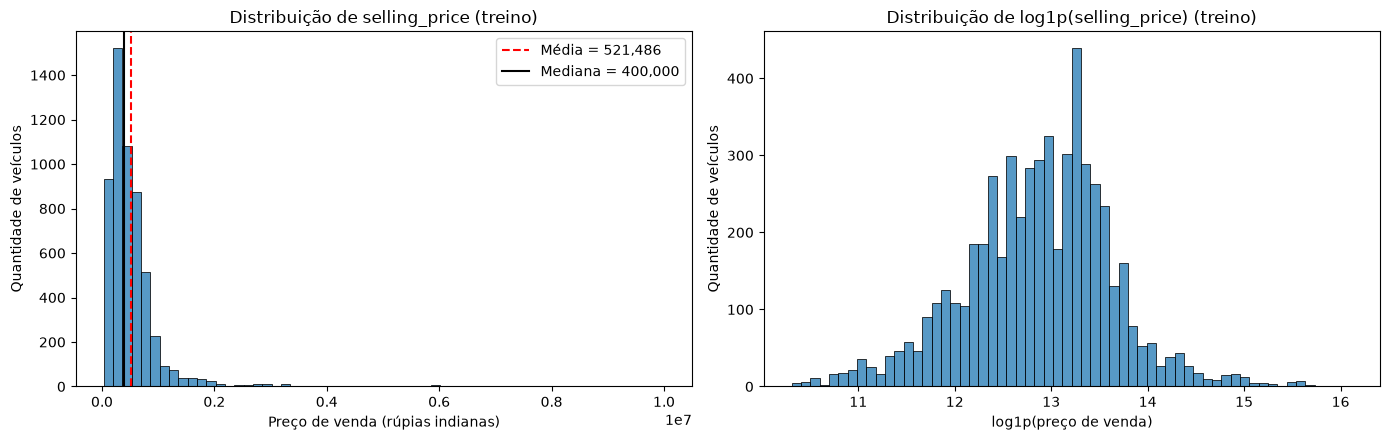

Assimetria original: 5.48 | Assimetria após log1p: -0.13


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(y_train, bins=60, ax=axes[0])
axes[0].axvline(y_train.mean(), color="red", linestyle="--", label=f"Média = {y_train.mean():,.0f}")
axes[0].axvline(y_train.median(), color="black", label=f"Mediana = {y_train.median():,.0f}")
axes[0].set(title="Distribuição de selling_price (treino)", xlabel="Preço de venda (rúpias indianas)", ylabel="Quantidade de veículos")
axes[0].legend()

sns.histplot(np.log1p(y_train), bins=60, ax=axes[1])
axes[1].set(title="Distribuição de log1p(selling_price) (treino)", xlabel="log1p(preço de venda)", ylabel="Quantidade de veículos")

plt.tight_layout()
plt.show()

print(f"Assimetria original: {y_train.skew():.2f} | Assimetria após log1p: {np.log1p(y_train).skew():.2f}")

No treino, o preço vai de 29.999 a 10.000.000 rúpias. A média (521.486) é 30% maior que a mediana (400.000), a assimetria é 5,48 e a curtose 50,92: a distribuição tem uma cauda longa à direita, com a grande maioria dos carros abaixo de ~1 milhão e poucos veículos muito caros puxando a média para cima.

Com `log1p`, a assimetria cai para -0,13 e a distribuição fica próxima de simétrica. Isso importa para a APS2, porque modelos que minimizam erro quadrático seriam muito influenciados pela cauda de preços altos. Por enquanto **não vamos alterar o target**; só registramos que `log1p(selling_price)` é uma candidata forte para a modelagem, e usaremos a escala log nas visualizações de preço.

In [26]:
p99_price = y_train.quantile(0.99)
print(f"Percentil 99 do preço: {p99_price:,.0f} | veículos acima dele no treino: {(y_train > p99_price).sum()}")

train_df.assign(name=car_names).nlargest(10, TARGET)[
    ["name", "year", "km_driven", "max_power_bhp", "transmission", "seller_type", TARGET]
]

Percentil 99 do preço: 2,880,500 | veículos acima dele no treino: 56


,name,year,km_driven,max_power_bhp,transmission,seller_type,selling_price
170,Volvo XC90 T8 Excellence BSIV,2017,30000,400.00,Automatic,Individual,10000000
4288,Audi A6 35 TFSI Matrix,2019,23600,187.74,Automatic,Dealer,6523000
4286,Audi A6 35 TFSI Matrix,2019,7800,187.74,Automatic,Dealer,6223000
136,Mercedes-Benz S-Class S 350 CDI,2017,37000,254.79,Automatic,Dealer,6000000
1017,BMW 6 Series GT 630d Luxury Line,2018,28156,261.40,Automatic,Dealer,6000000
4143,BMW 6 Series GT 630d Luxury Line,2018,27000,261.40,Automatic,Dealer,6000000
4287,Audi A6 35 TFSI Matrix,2019,11500,187.74,Automatic,Dealer,5923000
148,Mercedes-Benz S-Class S 350 CDI,2017,47000,282.00,Automatic,Dealer,5850000
139,BMW X4 M Sport X xDrive20d,2019,7500,190.00,Automatic,Dealer,5800000
6326,BMW X4 M Sport X xDrive20d,2019,21000,190.00,Automatic,Dealer,5800000


Acima do percentil 99 (2.880.500) existem 56 carros no treino. Os 10 mais caros são Volvo XC90 T8, Audi A6, Mercedes-Benz S-Class, BMW 6 Series GT e BMW X4: todos automáticos, de 2017 a 2019, com baixa quilometragem (7.500 a 47.000 km) e potência entre 187 e 400 bhp. São justamente os carros que esperaríamos que fossem caros, então esses preços parecem **legítimos**, e não erros de digitação.

**Decisão:** não vamos remover preços altos só por serem altos. Eles representam um segmento real (carros premium) que o modelo precisará aprender.

## 6. Análise univariada numérica (treino)

Estatísticas descritivas de todas as variáveis numéricas, incluindo a assimetria e a quantidade de missing.

In [27]:
numeric_columns = train_df.select_dtypes(include="number").columns.tolist()

numeric_summary = train_df[numeric_columns].describe().T
numeric_summary["skew"] = train_df[numeric_columns].skew()
numeric_summary["missing"] = train_df[numeric_columns].isna().sum()
numeric_summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,missing
year,5540.0,2013.40,4.10,1983.00,2011.0,2014.00,2017.00,2020.0,-1.04,0
km_driven,5540.0,74063.13,52817.00,1.00,40000.0,70000.00,100000.00,1500000.0,5.02,0
seats,5368.0,5.44,1.00,2.00,5.0,5.00,5.00,14.0,1.90,172
engine_cc,5368.0,1436.97,500.03,624.00,1197.0,1248.00,1498.00,3604.0,1.19,172
max_power_bhp,5369.0,88.00,32.35,0.00,67.1,81.83,100.00,400.0,1.73,171
mileage_value,5368.0,19.45,4.07,0.00,16.8,19.40,22.54,42.0,-0.15,172
torque_nm,5341.0,172.21,86.18,47.07,110.0,160.00,200.06,789.0,1.38,199
selling_price,5540.0,521486.38,531779.46,29999.00,250000.0,400000.00,640000.00,10000000.0,5.48,0


Pontos que chamam atenção nas estatísticas do treino:
- `km_driven` tem assimetria de 5,02, máximo de 1.500.000 km (o 3º quartil é 100.000 km) e mínimo de 1 km.
- `year` vai de 1983 a 2020, com assimetria negativa (-1,04): a maioria dos carros é recente (mediana 2014).
- `max_power_bhp` e `mileage_value` têm mínimo 0, o que não faz sentido fisicamente.
- `torque_nm` tem máximo de 789 Nm, bem acima do 3º quartil (~200 Nm).
- `seats` tem 1º quartil, mediana e 3º quartil iguais a 5, com valores de 2 a 14.
- As features técnicas têm entre 171 e 199 missing (~3%); `year` e `km_driven` não têm missing.

Para as visualizações escolhemos `km_driven` (a feature mais assimétrica), `year` (maior correlação de Spearman com o preço, como veremos na seção 9) e `max_power_bhp` (maior correlação de Pearson com o preço). O target já foi visualizado na seção 5.

In [28]:
def plot_histogram(column, title, xlabel, bins=50, log_x=False, discrete=False):
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.histplot(train_df[column].dropna(), bins=bins, log_scale=log_x, discrete=discrete, ax=ax)
    ax.axvline(train_df[column].median(), color="black", linestyle="--", label=f"Mediana = {train_df[column].median():,.1f}")
    ax.set(title=title, xlabel=xlabel, ylabel="Quantidade de veículos")
    ax.legend()
    plt.tight_layout()
    plt.show()

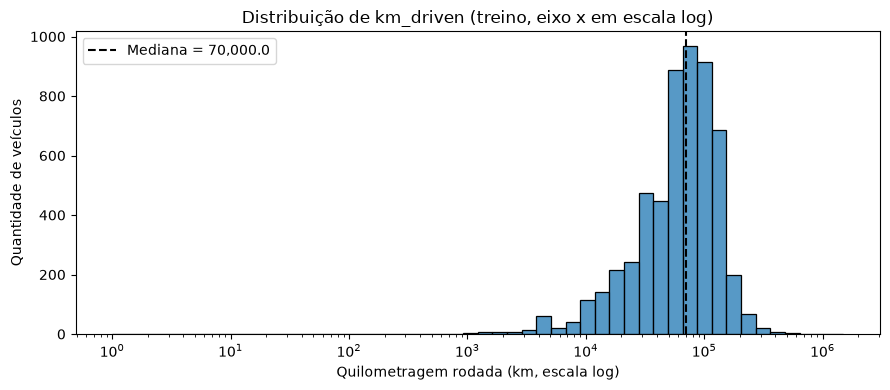

In [29]:
plot_histogram("km_driven", "Distribuição de km_driven (treino, eixo x em escala log)", "Quilometragem rodada (km, escala log)", log_x=True)

Mesmo em escala log, `km_driven` fica concentrado entre ~10⁴ e ~2×10⁵ km, com mediana de 70.000 km. Existem poucos carros abaixo de 10⁴ km e um valor isolado muito à esquerda (1 km), além de uma cauda à direita que chega a 1,5×10⁶ km. A forte assimetria na escala original (5,02) indica que `log1p` é adequado para essa feature, e isso será incorporado ao pipeline. Os extremos serão analisados na seção 8.

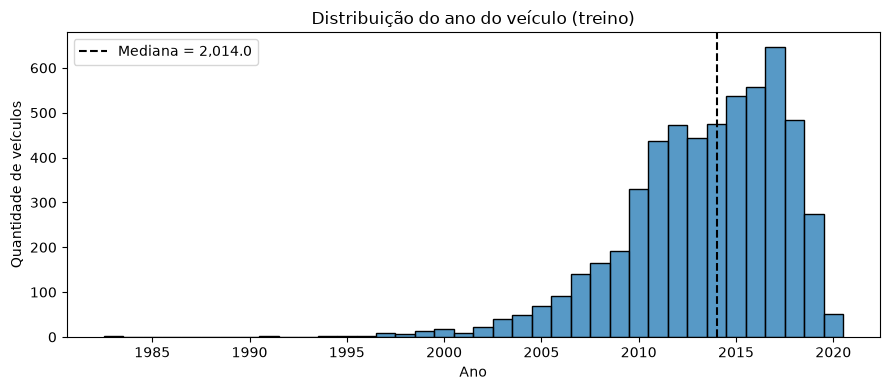

In [30]:
plot_histogram("year", "Distribuição do ano do veículo (treino)", "Ano", discrete=True)

A quantidade de carros cresce com o ano até o pico em 2017, e cai em 2019 e principalmente em 2020 (provavelmente porque os dados foram coletados por volta de 2020 e há menos carros tão novos à venda como usados). A metade central está entre 2011 e 2017, e anos anteriores a 2005 são raros, com o mais antigo em 1983. Esses carros antigos são poucos, mas plausíveis, então não serão removidos. Como `year` não tem missing nem valores impossíveis, basta padronizá-la.

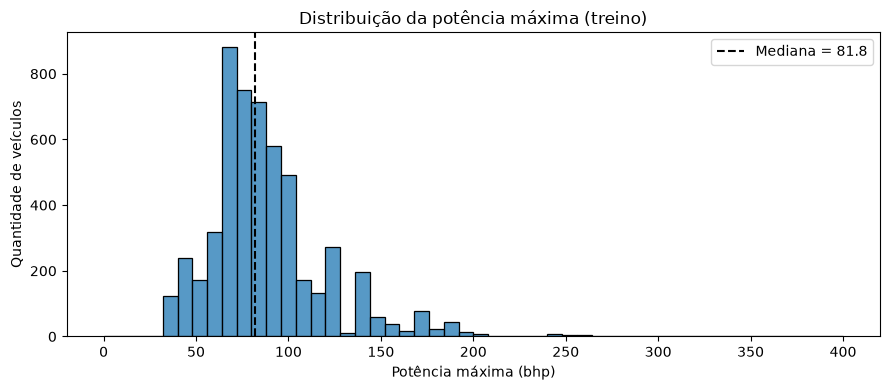

In [31]:
plot_histogram("max_power_bhp", "Distribuição da potência máxima (treino)", "Potência máxima (bhp)")

A maioria dos carros tem entre ~35 e ~120 bhp (Q1 = 67,1; Q3 = 100), com mediana de 81,8 bhp e picos em valores de versões de motor muito comuns. A cauda à direita (assimetria 1,73) é formada por poucos carros acima de 200 bhp, chegando a 400 bhp (o Volvo XC90 T8 do top de preços). Também existe uma barra quase invisível em 0 bhp, que corresponde aos registros impossíveis já mencionados. A cauda alta é plausível (carros premium); o problema real está nos zeros.

## 7. Análise univariada categórica (treino)

In [32]:
categorical_columns_final = train_df.select_dtypes(exclude="number").columns.tolist()

for column in categorical_columns_final:
    counts = train_df[column].value_counts(dropna=False)
    freq_table = pd.DataFrame({"contagem": counts, "percentual (%)": (counts / len(train_df) * 100).round(2)})
    print(f"\n{column} ({train_df[column].nunique()} categorias)")
    print(freq_table.head(10))


fuel (4 categorias)
        contagem  percentual (%)
fuel                            
Diesel      3031           54.71
Petrol      2435           43.95
CNG           41            0.74
LPG           33            0.60

seller_type (3 categorias)
                  contagem  percentual (%)
seller_type                               
Individual            4972           89.75
Dealer                 548            9.89
Trustmark Dealer        20            0.36

transmission (2 categorias)
              contagem  percentual (%)
transmission                          
Manual            5067           91.46
Automatic          473            8.54

owner (5 categorias)
                      contagem  percentual (%)
owner                                         
First Owner               3363           60.70
Second Owner              1593           28.75
Third Owner                451            8.14
Fourth & Above Owner       129            2.33
Test Drive Car               4            0.07

m

In [33]:
def plot_category_bar(column, title, xlabel, top_n=None):
    counts = train_df[column].value_counts()
    if top_n:
        counts = counts.head(top_n)
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(counts.index.astype(str), counts.values, color="steelblue")
    ax.bar_label(bars)
    ax.set(title=title, xlabel=xlabel, ylabel="Quantidade de veículos")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

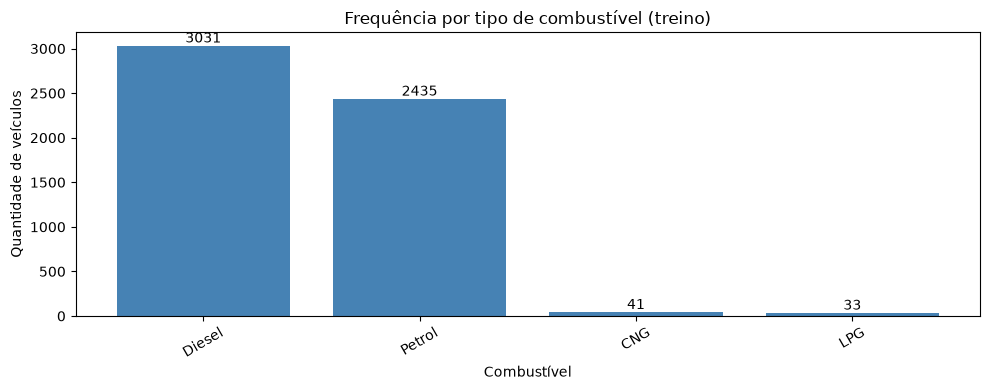

In [34]:
plot_category_bar("fuel", "Frequência por tipo de combustível (treino)", "Combustível")

Diesel (54,71%) e Petrol (43,95%) dominam o treino, enquanto CNG (41 carros, 0,74%) e LPG (33 carros, 0,60%) são raros. Com tão poucos exemplos, estatísticas dessas categorias (como a mediana de preço) são pouco estáveis, e o modelo terá pouca informação para aprender sobre elas. Mesmo assim vamos mantê-las: são categorias válidas, o One-Hot cria colunas próprias para elas, e elas explicam o uso de `mileage_unit = km/kg`.

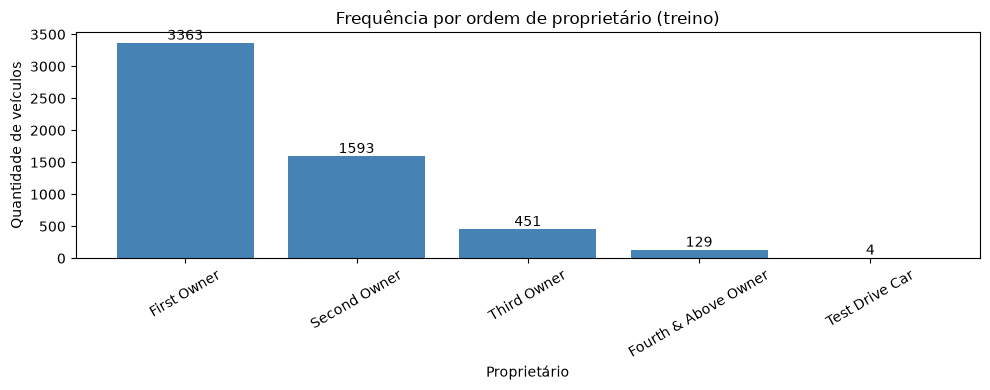

In [35]:
plot_category_bar("owner", "Frequência por ordem de proprietário (treino)", "Proprietário")

60,70% dos carros são de primeiro dono, 28,75% de segundo, 8,14% de terceiro e 2,33% de quarto dono ou mais. `Test Drive Car` tem apenas 4 registros no treino (0,07%). É uma categoria rara, mas representa um tipo real de veículo (carros de test drive vendidos por concessionárias), então não vamos removê-la; só registramos que qualquer conclusão sobre ela é frágil. Apesar de `owner` ter uma ordem natural (1º, 2º, 3º dono...), `Test Drive Car` não se encaixa nessa escala, o que reforça o uso de One-Hot em vez de uma codificação ordinal.

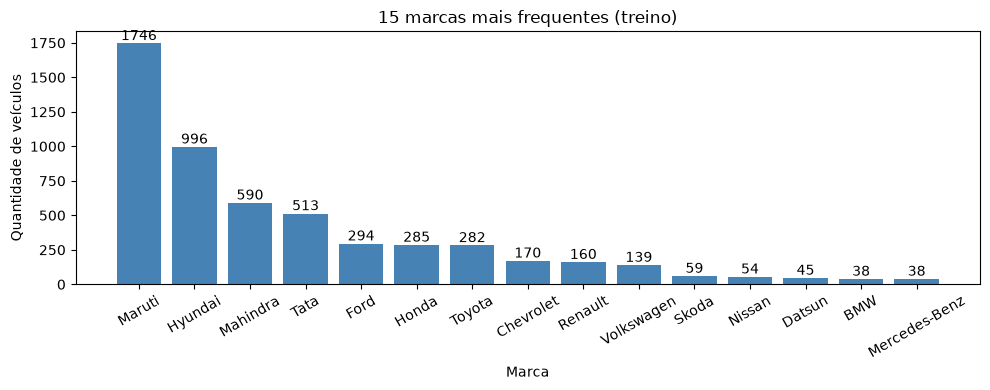

In [36]:
plot_category_bar("brand", "15 marcas mais frequentes (treino)", "Marca", top_n=15)

Mesmo após reduzir `name` para `brand`, a distribuição continua concentrada: Maruti (31,52%) e Hyundai (17,98%) somam quase metade do treino, e as 10 marcas mais frequentes cobrem 93,42% dos carros. O treino tem 30 das 32 marcas, e várias aparecem pouquíssimas vezes. Por isso vamos usar `OneHotEncoder(handle_unknown="ignore")`: se aparecer no teste, ou em dados futuros, uma marca que não existia no treino, ela recebe zero em todas as colunas de marca em vez de gerar erro.

## 8. Outliers (treino)

Vamos quantificar os extremos pela regra do IQR (1,5 × IQR), junto com percentis e mínimo/máximo. A regra do IQR aqui serve só para **sinalizar** valores estatisticamente extremos, não para remover automaticamente.

In [37]:
def iqr_summary(series):
    series = series.dropna()
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return pd.Series({
        "min": series.min(), "p1": series.quantile(0.01), "Q1": q1, "mediana": series.median(),
        "Q3": q3, "p99": series.quantile(0.99), "max": series.max(),
        "limite_inf": lower, "limite_sup": upper,
        "abaixo": (series < lower).sum(), "acima": (series > upper).sum(),
        "% fora": ((series < lower) | (series > upper)).mean() * 100,
    })

outlier_table = train_df[numeric_columns].apply(iqr_summary).T
outlier_table.round(2)

,min,p1,Q1,mediana,Q3,p99,max,limite_inf,limite_sup,abaixo,acima,% fora
year,1983.00,2000.0,2011.0,2014.00,2017.00,2019.0,2020.0,2002.00,2026.00,65.0,0.0,1.17
km_driven,1.00,5000.0,40000.0,70000.00,100000.00,243660.0,1500000.0,-50000.00,190000.00,0.0,134.0,2.42
seats,2.00,4.0,5.0,5.00,5.00,9.0,14.0,5.00,5.00,102.0,1085.0,22.11
engine_cc,624.00,796.0,1197.0,1248.00,1498.00,2967.0,3604.0,745.50,1949.50,20.0,980.0,18.63
max_power_bhp,0.00,37.0,67.1,81.83,100.00,190.0,400.0,17.75,149.35,2.0,257.0,4.82
mileage_value,0.00,11.1,16.8,19.40,22.54,28.4,42.0,8.19,31.15,12.0,5.0,0.32
torque_nm,47.07,59.0,110.0,160.00,200.06,430.0,789.0,-25.08,335.14,0.0,238.0,4.46
selling_price,29999.00,50780.0,250000.0,400000.00,640000.00,2880500.0,10000000.0,-335000.00,1225000.00,0.0,274.0,4.95


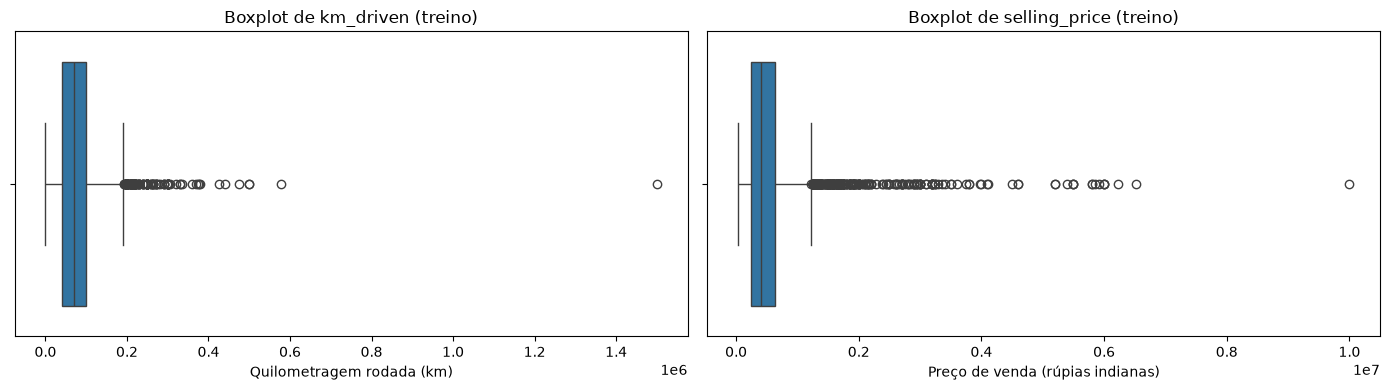

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x=train_df["km_driven"], ax=axes[0])
axes[0].set(title="Boxplot de km_driven (treino)", xlabel="Quilometragem rodada (km)")

sns.boxplot(x=train_df[TARGET], ax=axes[1])
axes[1].set(title="Boxplot de selling_price (treino)", xlabel="Preço de venda (rúpias indianas)")

plt.tight_layout()
plt.show()

Pela regra do IQR, as variáveis com mais pontos "fora" são `seats` (22,11%) e `engine_cc` (18,63%). Nesses casos isso não indica erro: em `seats`, Q1 = Q3 = 5, então qualquer carro com 4, 7 ou 8 lugares vira "outlier"; em `engine_cc`, os motores acima de 1949,5 CC são SUVs e sedãs maiores, que existem de verdade. Isso mostra por que não faz sentido remover automaticamente tudo o que está fora do IQR.

Em `km_driven` (134 carros acima de 190.000 km, 2,42%) e `selling_price` (274 acima de 1.225.000, 4,95%), os boxplots mostram caudas longas à direita, e em cada um existe um ponto muito isolado dos demais: 1.500.000 km e 10.000.000 de preço. No preço, já vimos que o extremo é um Volvo XC90 T8, compatível com o valor. Em `km_driven`, precisamos olhar os casos mais altos individualmente.

In [39]:
REFERENCE_YEAR = X_train["year"].max() + 1  # aproximação do ano de coleta dos anúncios

km_check = train_df.assign(name=car_names, car_age=REFERENCE_YEAR - train_df["year"])
km_check["km_per_year"] = km_check["km_driven"] / km_check["car_age"]

print("Percentis altos de km_driven:")
print(train_df["km_driven"].quantile([0.95, 0.99, 0.999]).round(0))
print("\nPercentis altos de km por ano de uso:")
print(km_check["km_per_year"].quantile([0.95, 0.99, 0.999]).round(0))

km_check.nlargest(10, "km_driven")[["name", "year", "car_age", "km_driven", "km_per_year", "owner", "seller_type", TARGET]]

Percentis altos de km_driven:
0.950    158000.0
0.990    243660.0
0.999    432454.0
Name: km_driven, dtype: float64

Percentis altos de km por ano de uso:
0.950    23263.0
0.990    35000.0
0.999    60000.0
Name: km_per_year, dtype: float64


,name,year,car_age,km_driven,km_per_year,owner,seller_type,selling_price
1646,Mahindra XUV500 W6 2WD,2012,9,1500000,166666.666667,First Owner,Individual,500000
3183,Maruti Wagon R LXI Minor,2010,11,577414,52492.181818,Second Owner,Individual,194000
5744,Toyota Innova 2.5 EV Diesel PS 7 Seater BSIII,2011,10,500000,50000.000000,Second Owner,Individual,350000
3284,Maruti Wagon R VXI BS IV,2011,10,500000,50000.000000,Second Owner,Individual,229999
4411,Mahindra Scorpio M2DI,2011,10,475000,47500.000000,Third Owner,Individual,400000
4485,Toyota Innova 2.5 VX (Diesel) 7 Seater,2013,8,440000,55000.000000,Second Owner,Individual,750000
4737,Toyota Innova 2.5 VX (Diesel) 7 Seater BS IV,2010,11,426000,38727.272727,First Owner,Individual,950000
2080,Mahindra Bolero SLE,2010,11,380000,34545.454545,Second Owner,Individual,260000
6104,Toyota Innova 2.5 V Diesel 8-seater,2007,14,376412,26886.571429,Second Owner,Individual,350000
1821,Toyota Innova 2.5 G (Diesel) 7 Seater BS IV,2011,10,375000,37500.000000,First Owner,Individual,650000


In [40]:
print("Veículos com km_driven < 1000:", (train_df["km_driven"] < 1000).sum())
print(km_check.nsmallest(5, "km_driven")[["name", "year", "km_driven", "owner", TARGET]])

print("\nValores iguais a zero nas features técnicas:")
print((train_df[["engine_cc", "max_power_bhp", "mileage_value", "torque_nm", "seats"]] == 0).sum())

print("\nMaiores torque_nm e torque por litro de motor:")
km_check["torque_per_liter"] = km_check["torque_nm"] / (km_check["engine_cc"] / 1000)
print(km_check.nlargest(6, "torque_nm")[["name", "engine_cc", "max_power_bhp", "torque_nm", "torque_per_liter"]].round(1))
print(km_check.nlargest(6, "torque_per_liter")[["name", "engine_cc", "max_power_bhp", "torque_nm", "torque_per_liter"]].round(1))

Veículos com km_driven < 1000: 1
                                        name  year  km_driven  \
6737  Maruti Eeco 5 STR With AC Plus HTR CNG  2011          1   
2714                    Maruti Swift AMT VXI  2020       1000   
6450                    Hyundai Santro Magna  2020       1000   
6409                        Maruti Swift LXI  2020       1000   
5318                    Datsun RediGO SV 1.0  2019       1300   

                     owner  selling_price  
6737  Fourth & Above Owner         209000  
2714           First Owner         654000  
6450           First Owner         500000  
6409           First Owner         445000  
5318           First Owner         325000  

Valores iguais a zero nas features técnicas:
engine_cc         0
max_power_bhp     2
mileage_value    12
torque_nm         0
seats             0
dtype: int64

Maiores torque_nm e torque por litro de motor:
                                  name  engine_cc  max_power_bhp  torque_nm  \
897                       

Separando **valor estatisticamente extremo** de **valor semanticamente impossível**:

- `km_driven = 1.500.000` (Mahindra XUV500 2012, primeiro dono): seriam ~166.667 km por ano, mais de 450 km **todos os dias** durante 9 anos. O segundo maior valor (577.414 km) já cai para ~52.500 km/ano, alto mas possível (táxi, viagens), e o percentil 99,9 de km por ano é 60.000. Consideramos 1.500.000 km inconsistente.
- `km_driven = 1` (Maruti Eeco 2011, **quarto dono ou mais**): um carro com 4 ou mais donos não pode ter rodado 1 km. Os próximos menores valores (1.000 km) são carros de 2019/2020 de primeiro dono, o que é coerente.
- `km_driven` entre 190.000 e 577.414 km: extremo, mas plausível → mantido.
- `max_power_bhp = 0` (2 carros) e `mileage_value = 0` (12 carros): um carro não tem potência nem consumo zero; são valores ausentes registrados como 0.
- `torque_nm = 789` (Maruti Zen D, 1527 CC e 58 bhp; 3 registros): dá 516,7 Nm por litro de motor. Os maiores valores legítimos ficam bem abaixo (Volvo XC90 T8 híbrido: 325 Nm/L; Volvo XC60 D5: 243,8 Nm/L). É bem provável que seja um erro de digitação, mas como não podemos confirmar o valor correto, tratamos como inconsistente.
- `selling_price`, `engine_cc`, `seats` (2 lugares em picapes e 14 em vans) e anos antigos: extremos plausíveis → mantidos.

**Estratégia escolhida:**
1. Não removemos linhas. Valores impossíveis viram `NaN` por **regras fixas de domínio** (`km_driven < 100` ou `> 1.000.000`; potência ou consumo `<= 0`; torque acima de 400 Nm por litro) e depois serão imputados pela mediana do treino. Como essas regras não dependem de estatísticas dos dados, podem ser aplicadas da mesma forma ao treino, ao teste e a dados futuros; por isso entram como primeiro passo do pipeline (`FunctionTransformer`).
2. Em `km_driven`, positiva e muito assimétrica, aplicaremos `log1p` dentro do pipeline, reduzindo o peso dos valores altos plausíveis sem descartá-los.
3. O target não é alterado.

Abaixo aplicamos essas regras ao treino, e o restante da EDA usa essa versão.

In [41]:
KM_DRIVEN_MIN, KM_DRIVEN_MAX = 100, 1_000_000
TORQUE_PER_LITER_MAX = 400  # Nm por litro de cilindrada

def mark_implausible_as_nan(X):
    # Regras fixas de domínio (sem estatísticas dos dados): valores impossíveis viram NaN
    X = X.copy()
    km_invalid = (X["km_driven"] < KM_DRIVEN_MIN) | (X["km_driven"] > KM_DRIVEN_MAX)
    X["km_driven"] = X["km_driven"].mask(km_invalid)
    for column in ["max_power_bhp", "mileage_value"]:
        X[column] = X[column].mask(X[column] <= 0)
    torque_per_liter = X["torque_nm"] / (X["engine_cc"] / 1000)
    X["torque_nm"] = X["torque_nm"].mask(torque_per_liter > TORQUE_PER_LITER_MAX)
    return X

train_df_raw = train_df
train_df = mark_implausible_as_nan(train_df_raw)  # versão usada no restante da EDA

new_missing = train_df.isna().sum() - train_df_raw.isna().sum()
print("Valores marcados como NaN no treino:")
print(new_missing[new_missing > 0])

Valores marcados como NaN no treino:
km_driven         2
max_power_bhp     2
mileage_value    12
torque_nm         3
dtype: int64


## 9. Análise bivariada e multivariada numérica (treino)

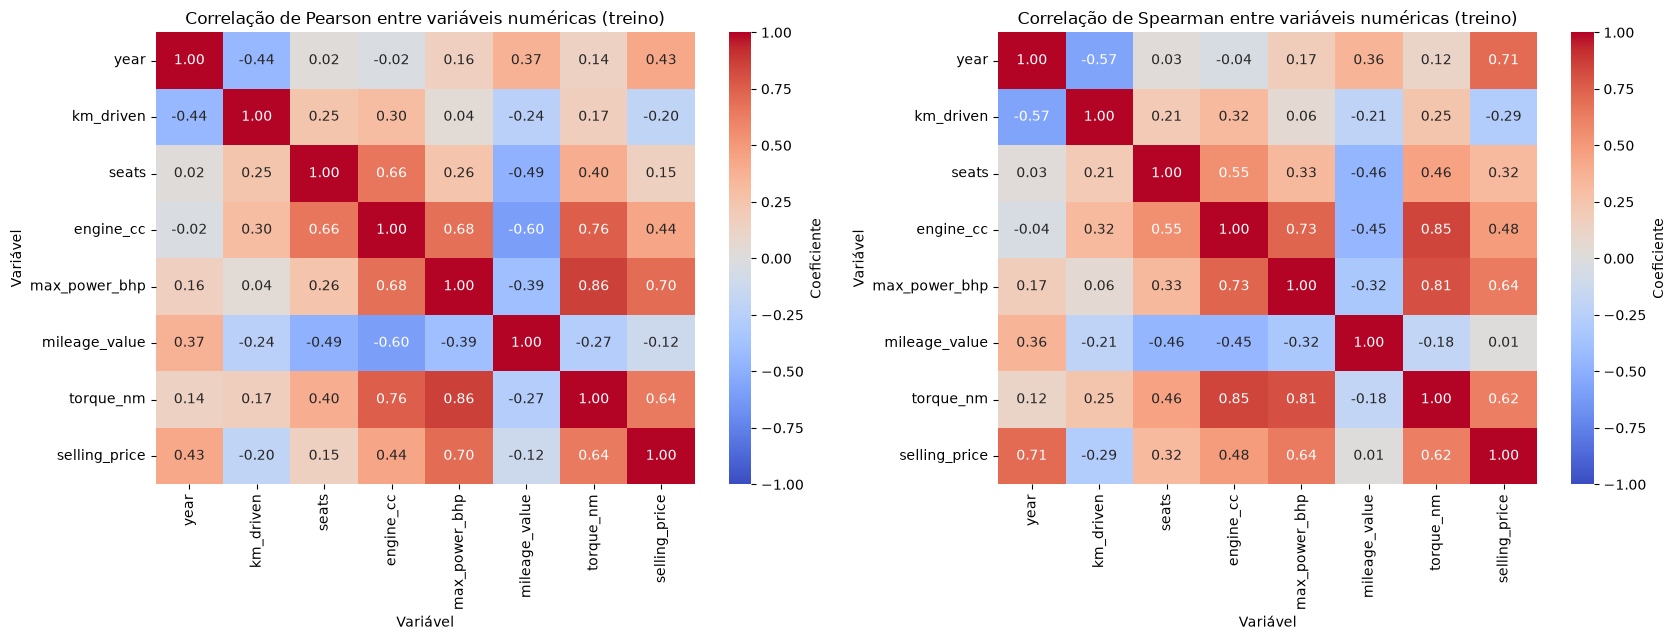

,pearson,spearman
year,0.426,0.705
max_power_bhp,0.698,0.639
torque_nm,0.644,0.622
engine_cc,0.443,0.485
seats,0.153,0.319
km_driven,-0.198,-0.288
mileage_value,-0.118,0.013


In [42]:
pearson_corr = train_df[numeric_columns].corr(method="pearson")
spearman_corr = train_df[numeric_columns].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
for ax, corr, method in zip(axes, [pearson_corr, spearman_corr], ["Pearson", "Spearman"]):
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax, cbar_kws={"label": "Coeficiente"})
    ax.set(title=f"Correlação de {method} entre variáveis numéricas (treino)", xlabel="Variável", ylabel="Variável")
plt.tight_layout()
plt.show()

target_correlations = pd.DataFrame({
    "pearson": pearson_corr[TARGET],
    "spearman": spearman_corr[TARGET],
}).drop(TARGET).sort_values("spearman", key=abs, ascending=False)
target_correlations.round(3)

Relações com `selling_price` no treino:
- `year`: Pearson 0,426 e Spearman 0,705. É a maior relação monotônica, e a diferença entre os coeficientes indica que a relação não é linear na escala original do preço.
- `max_power_bhp`: Pearson 0,698 (a maior relação linear) e Spearman 0,639.
- `torque_nm` (0,644 / 0,622) e `engine_cc` (0,443 / 0,485): relações positivas moderadas.
- `km_driven` (-0,198 / -0,288): carros mais rodados tendem a ser mais baratos, mas a relação isolada é fraca.
- `seats` (0,153 / 0,319) e `mileage_value` (-0,118 / 0,013): relações fracas.

Entre as próprias features existe um bloco técnico bem correlacionado: `max_power_bhp` × `torque_nm` (Pearson 0,86), `engine_cc` × `torque_nm` (0,76; Spearman 0,85) e `engine_cc` × `max_power_bhp` (0,68). Também vemos `engine_cc` × `seats` (0,66), `engine_cc` × `mileage_value` (-0,60) e `year` × `km_driven` (-0,44; Spearman -0,57), mostrando que carros mais antigos rodaram mais. Essa redundância (multicolinearidade) deve ser considerada na APS2 e sugere que o PCA conseguirá resumir parte dessas variáveis. Lembrando que correlação descreve associação e não indica causalidade.

Para os scatter plots escolhemos `max_power_bhp` (maior Pearson) e `year` (maior Spearman). O terceiro seria `torque_nm`, mas ele tem correlação de 0,86 com `max_power_bhp` e o gráfico repetiria praticamente a mesma informação; por isso usamos `engine_cc`, a variável técnica seguinte em correlação com o preço.

In [43]:
def plot_scatter_vs_price(column, xlabel):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(train_df[column], train_df[TARGET], s=10, alpha=0.35)
    ax.set_yscale("log")
    ax.set(title=f"{column} × selling_price (treino, eixo y em escala log)", xlabel=xlabel, ylabel="Preço de venda (rúpias, escala log)")
    plt.tight_layout()
    plt.show()

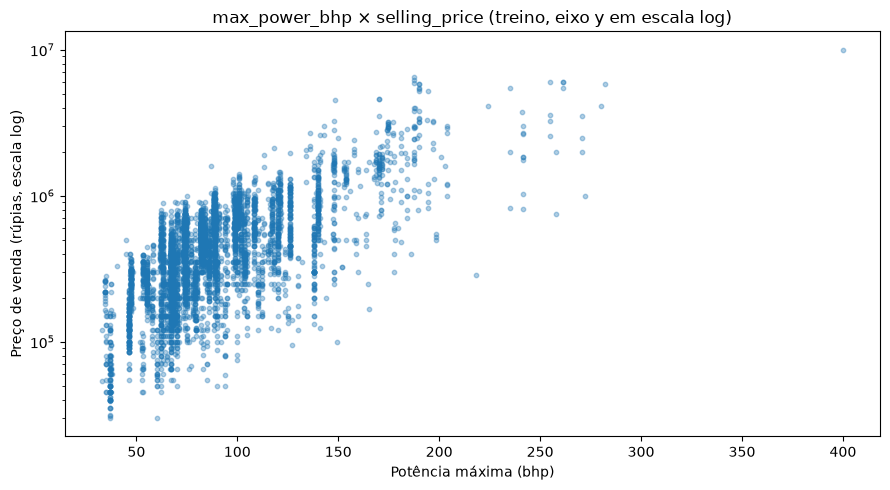

In [44]:
plot_scatter_vs_price("max_power_bhp", "Potência máxima (bhp)")

A relação é claramente positiva: carros mais potentes tendem a ter preços maiores. Com o preço em escala log, a nuvem sobe de forma aproximadamente linear até ~200 bhp, o que indica que na escala original a relação não é linear (o preço cresce de forma acelerada com a potência). Os pontos formam colunas verticais porque muitos carros compartilham a mesma versão de motor. A dispersão para uma mesma potência é grande (entre ~70 e ~100 bhp há preços de menos de 10⁵ até mais de 10⁶), mostrando que potência sozinha não explica o preço. Na escala original essa dispersão aumentaria com a potência (heterocedasticidade), o que é mais um motivo para considerar `log1p` no target. Acima de 200 bhp há poucos carros, todos de preço alto.

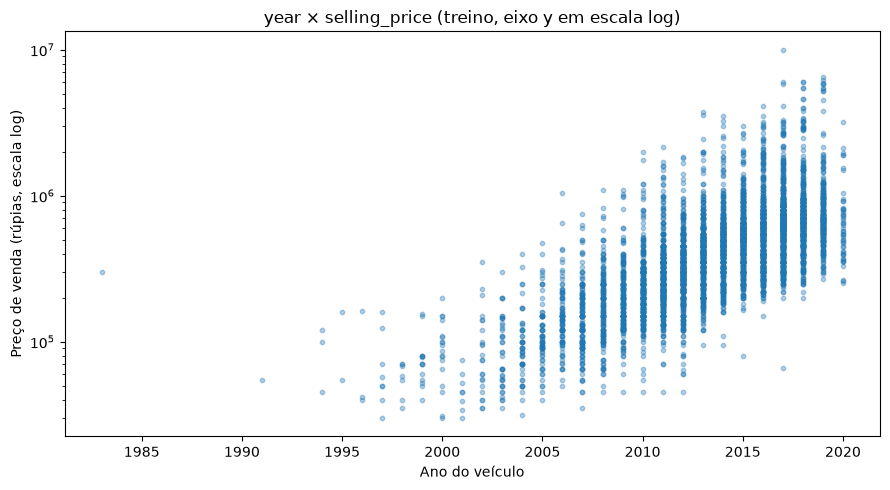

In [45]:
plot_scatter_vs_price("year", "Ano do veículo")

Carros mais novos tendem a ser mais caros, e em escala log a subida é bem regular a partir de ~2000. É a feature com maior Spearman (0,705) mas com Pearson bem menor (0,426), o que combina com o gráfico: a relação é monotônica, mas não linear na escala original. Para um mesmo ano a dispersão é grande, e nos anos recentes ela fica ainda maior, porque convivem carros populares e premium (em 2017 há preços de menos de 10⁵ até 10⁷). O ponto isolado de 1983 tem preço relativamente alto para a idade, possivelmente um carro antigo valorizado, mas com um único caso não dá para concluir nada.

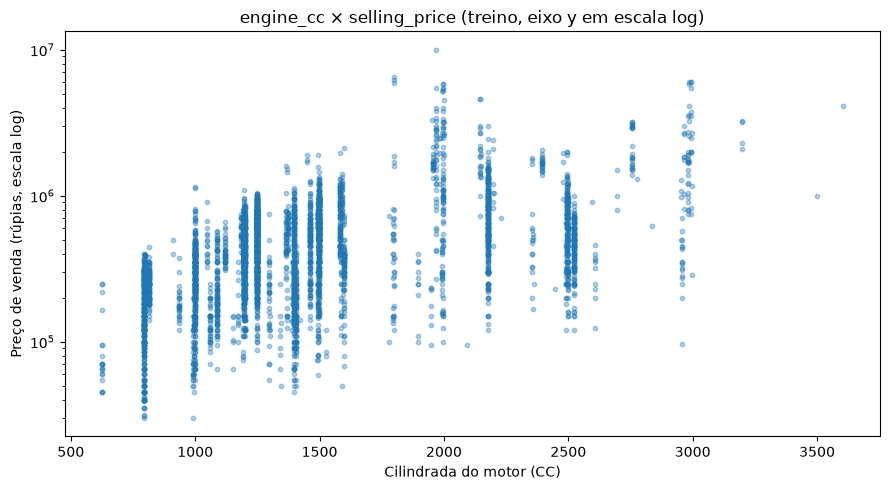

In [46]:
plot_scatter_vs_price("engine_cc", "Cilindrada do motor (CC)")

A relação é positiva, mas mais fraca e menos regular do que nas duas anteriores (Pearson 0,443; Spearman 0,485). Como a cilindrada assume poucos valores padronizados (~800, 1000, 1200, 1500, 2000, 2500, 3000 CC), os pontos formam faixas verticais separadas. Um detalhe importante é que a faixa de ~2500 CC concentra preços menores do que a faixa de ~2000 CC, ou seja, a relação não é monotônica em todo o intervalo: um motor maior não significa necessariamente um carro mais caro, e o tipo de veículo e a marca também parecem importar.

## 10. Categóricas × target (`selling_price`)

O enunciado fala em `income`, mas no nosso projeto o target é `selling_price`. Primeiro uma tabela com contagem, média e mediana do preço por categoria.

In [47]:
def price_by_category(column):
    return (
        train_df.groupby(column)[TARGET]
        .agg(contagem="count", media="mean", mediana="median")
        .sort_values("mediana", ascending=False)
        .round(0)
    )

for column in ["transmission", "fuel", "owner", "seller_type"]:
    print(f"\n{column}")
    print(price_by_category(column))


transmission
              contagem      media   mediana
transmission                               
Automatic          473  1362395.0  861999.0
Manual            5067   442988.0  380000.0

fuel
        contagem     media   mediana
fuel                                
Diesel      3031  646235.0  520000.0
CNG           41  309780.0  330000.0
Petrol      2435  374158.0  300000.0
LPG           33  197606.0  191000.0

owner
                      contagem      media    mediana
owner                                               
Test Drive Car               4  5004750.0  6073000.0
First Owner               3363   623454.0   509999.0
Second Owner              1593   385262.0   300000.0
Third Owner                451   287690.0   229999.0
Fourth & Above Owner       129   223791.0   185000.0

seller_type
                  contagem     media   mediana
seller_type                                   
Trustmark Dealer        20  751750.0  662500.0
Dealer                 548  962319.0  630000.0
Ind

In [48]:
OWNER_ORDER = ["Test Drive Car", "First Owner", "Second Owner", "Third Owner", "Fourth & Above Owner"]

def plot_box_by_category(numeric, category, title, ylabel, log_y=False, order=None):
    if order is None:
        order = train_df.groupby(category)[numeric].median().sort_values(ascending=False).index.tolist()
    fig, ax = plt.subplots(figsize=(10, 4.5))
    sns.boxplot(data=train_df, x=category, y=numeric, order=order, ax=ax)
    if log_y:
        ax.set_yscale("log")
    ax.set(title=title, xlabel=category, ylabel=ylabel)
    ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.show()

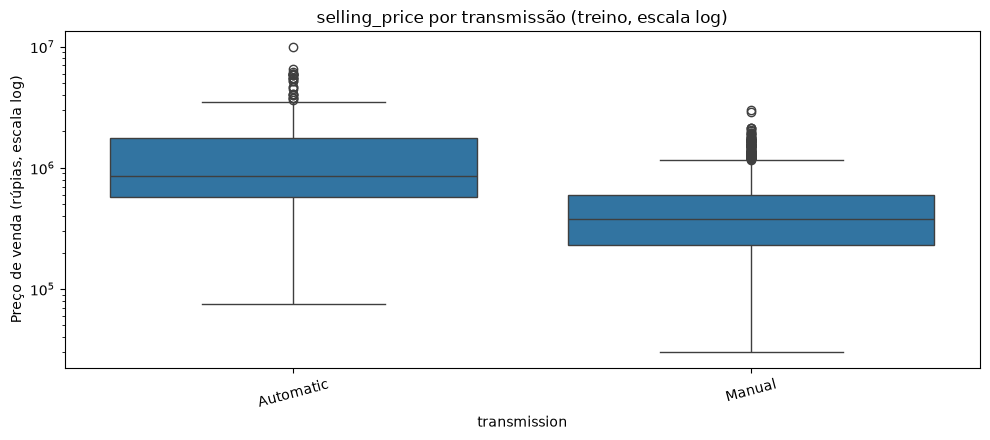

In [49]:
plot_box_by_category(TARGET, "transmission", "selling_price por transmissão (treino, escala log)", "Preço de venda (rúpias, escala log)", log_y=True)

Carros automáticos têm mediana de 861.999, contra 380.000 dos manuais (≈2,3 vezes), e a média dos automáticos (1.362.395) fica ainda mais distante por causa dos carros premium. No boxplot, o 1º quartil dos automáticos fica próximo do 3º quartil dos manuais. Porém, automáticos são só 473 carros (8,54%), e na seção 11 veremos que eles também são bem mais potentes, então essa diferença pode vir de outras características dos carros e não do tipo de câmbio em si.

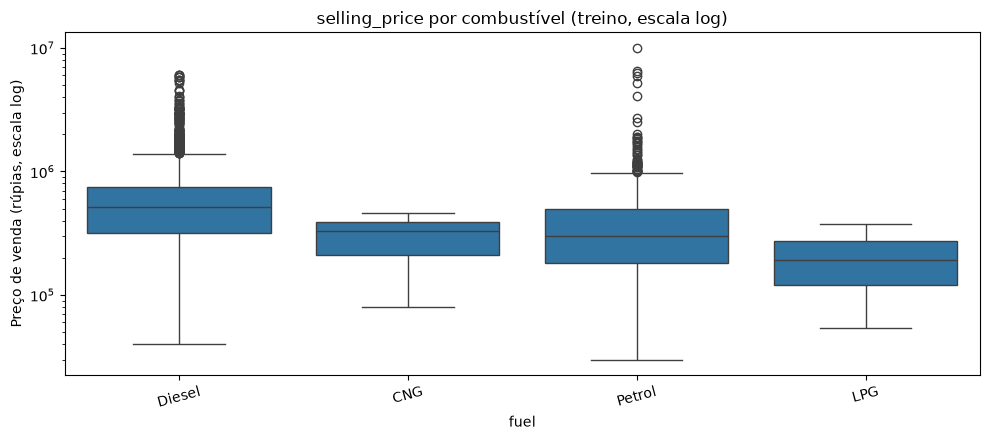

In [50]:
plot_box_by_category(TARGET, "fuel", "selling_price por combustível (treino, escala log)", "Preço de venda (rúpias, escala log)", log_y=True)

Diesel tem a maior mediana (520.000), seguido de CNG (330.000), Petrol (300.000) e LPG (191.000). Diesel e Petrol têm muitos pontos acima do bigode superior (carros caros), enquanto CNG e LPG têm faixas de preço estreitas e nenhum carro caro. CNG e LPG têm apenas 41 e 33 carros, então suas medianas são pouco estáveis. A mediana do Diesel é ~73% maior que a do Petrol, mas isso não significa que o combustível causa o preço maior: o tipo de carro que usa diesel pode ser diferente.

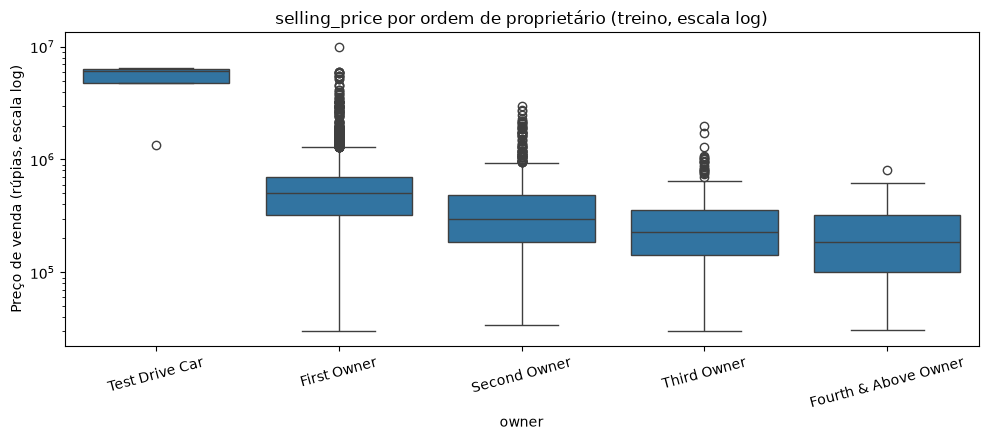

In [51]:
plot_box_by_category(TARGET, "owner", "selling_price por ordem de proprietário (treino, escala log)", "Preço de venda (rúpias, escala log)", log_y=True, order=OWNER_ORDER)

O preço cai de forma consistente conforme aumenta o número de donos: mediana de 509.999 (primeiro dono), 300.000 (segundo), 229.999 (terceiro) e 185.000 (quarto ou mais). `Test Drive Car` tem mediana de 6.073.000, mas com só 4 carros esse valor é muito instável e não deve ser generalizado. Como veremos na próxima seção, `owner` está fortemente ligado à idade do carro, então essa queda reflete, pelo menos em parte, o fato de carros com mais donos serem mais antigos.

## 11. Numéricas × categóricas (treino)

In [52]:
for numeric, category in [("year", "owner"), ("max_power_bhp", "transmission"), ("km_driven", "fuel")]:
    print(f"\nMediana de {numeric} por {category}:")
    print(train_df.groupby(category)[numeric].median())


Mediana de year por owner:
owner
First Owner             2016.0
Fourth & Above Owner    2008.0
Second Owner            2012.0
Test Drive Car          2019.0
Third Owner             2010.0
Name: year, dtype: float64

Mediana de max_power_bhp por transmission:
transmission
Automatic    126.66
Manual        80.00
Name: max_power_bhp, dtype: float64

Mediana de km_driven por fuel:
fuel
CNG       60000.0
Diesel    80000.0
LPG       80000.0
Petrol    50000.0
Name: km_driven, dtype: float64


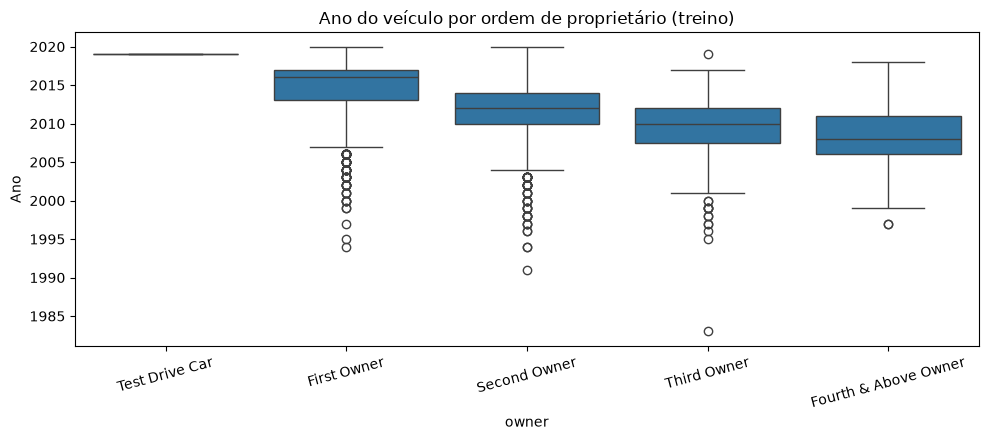

In [53]:
plot_box_by_category("year", "owner", "Ano do veículo por ordem de proprietário (treino)", "Ano", order=OWNER_ORDER)

A mediana do ano cai conforme aumenta a ordem do proprietário: 2016 (primeiro dono), 2012 (segundo), 2010 (terceiro) e 2008 (quarto ou mais), e os 4 `Test Drive Car` são de 2019. Ou seja, `owner` e `year` carregam informação parcialmente sobreposta: carros com mais donos são mais velhos. Isso ajuda a interpretar a seção anterior (a queda de preço entre donos não é só efeito do número de donos) e reforça que não devemos tirar conclusões causais olhando uma variável isolada.

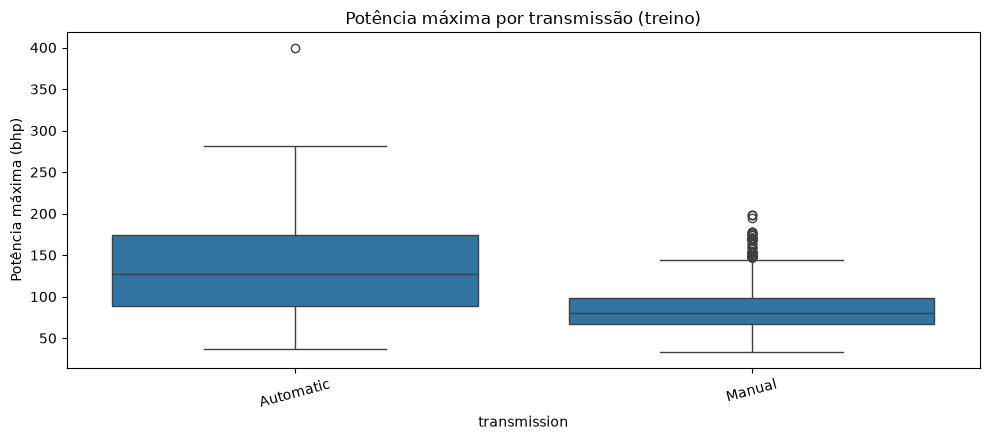

In [54]:
plot_box_by_category("max_power_bhp", "transmission", "Potência máxima por transmissão (treino)", "Potência máxima (bhp)")

Automáticos têm mediana de 126,66 bhp, contra 80,00 bhp dos manuais, e o 1º quartil dos automáticos (~90 bhp) fica próximo do 3º quartil dos manuais (~100 bhp). Os manuais se concentram numa faixa estreita, com outliers até ~200 bhp, enquanto os automáticos se espalham até ~280 bhp (e 400 bhp no Volvo). Portanto, a diferença de preço entre câmbios vista antes está misturada com diferença de potência: no dataset, câmbio automático está associado a carros mais potentes.

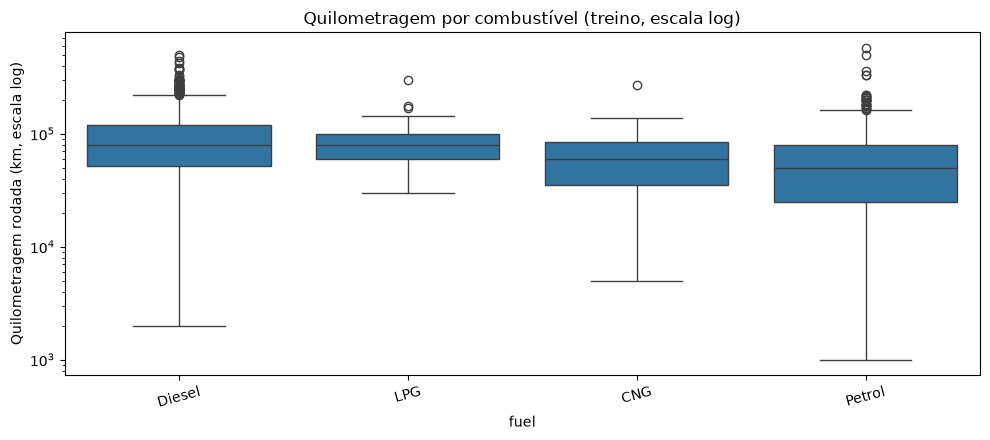

In [55]:
plot_box_by_category("km_driven", "fuel", "Quilometragem por combustível (treino, escala log)", "Quilometragem rodada (km, escala log)", log_y=True)

Diesel e LPG têm mediana de 80.000 km, CNG 60.000 km e Petrol 50.000 km. A diferença Diesel × Petrol é coerente com o uso típico (quem roda muito tende a preferir diesel), e é interessante notar que os carros diesel têm preço mediano maior (seção 10) mesmo sendo, em geral, mais rodados. Petrol tem a caixa mais larga, indo de carros pouco rodados até ~80.000 km no 3º quartil. Isso mostra que `fuel` e `km_driven` não são independentes, algo a ter em mente ao interpretar o efeito de cada uma.

## 12. Missing values

In [56]:
features_train_eda = train_df.drop(columns=TARGET)  # treino já com valores impossíveis como NaN

missing_train = pd.DataFrame({
    "missing": features_train_eda.isna().sum(),
    "% missing": (features_train_eda.isna().mean() * 100).round(2),
}).sort_values("% missing", ascending=False)
print(missing_train)

technical_features = ["engine_cc", "max_power_bhp", "mileage_value", "mileage_unit", "torque_nm", "seats"]
print("\nQuantidade de features técnicas ausentes por linha -> nº de linhas:")
print(features_train_eda[technical_features].isna().sum(axis=1).value_counts().sort_index())

               missing  % missing
torque_nm          202       3.65
mileage_value      184       3.32
max_power_bhp      173       3.12
seats              172       3.10
mileage_unit       172       3.10
engine_cc          172       3.10
km_driven            2       0.04
fuel                 0       0.00
year                 0       0.00
transmission         0       0.00
seller_type          0       0.00
owner                0       0.00
brand                0       0.00

Quantidade de features técnicas ausentes por linha -> nº de linhas:
0    5327
1      39
2       2
6     172
Name: count, dtype: int64


No treino, já com os valores impossíveis marcados como NaN, os missing se concentram nas features técnicas: `torque_nm` 3,65%, `mileage_value` 3,32%, `max_power_bhp` 3,12%, `seats`, `engine_cc` e `mileage_unit` 3,10%, e `km_driven` 0,04% (os 2 valores inconsistentes). As demais colunas não têm ausentes.

A contagem por linha mostra um padrão claro: 172 linhas não têm **nenhuma** das 6 informações técnicas, 39 linhas têm só 1 ausente e 2 linhas têm 2. Ou seja, a maior parte dos missing vem de anúncios sem ficha técnica, e não de falhas espalhadas. Remover essas linhas custaria ~3% do treino e jogaria fora preço, ano, quilometragem e categorias que estão completos; além disso, dados futuros também podem chegar incompletos. Por isso vamos imputar.

**Estratégia:**
- **Numéricas:** `SimpleImputer(strategy="median")`. Vimos que `km_driven` (assimetria 5,02), `max_power_bhp` (1,73), `torque_nm` (1,38) e `engine_cc` (1,19) são assimétricas e têm extremos plausíveis; a mediana é robusta a esses valores, enquanto a média seria puxada pela cauda. Em `seats`, a mediana (5) é justamente o valor típico.
- **Categóricas:** `SimpleImputer(strategy="most_frequent")`. Na prática só `mileage_unit` tem missing, e `kmpl` representa 98,7% dos valores preenchidos no treino. Uma categoria "desconhecido" acrescentaria pouca informação, porque essas linhas já são as mesmas sem nenhuma ficha técnica.
- Os imputadores ficam **dentro do pipeline** e são ajustados apenas com `X_train`; o teste só recebe `transform`, usando as medianas e modas aprendidas no treino.

## 13. Encoding

Features categóricas finais: `fuel`, `seller_type`, `transmission`, `owner`, `mileage_unit` e `brand`.

Vamos usar `OneHotEncoder(handle_unknown="ignore")` porque:
- essas variáveis são nominais: não existe ordem entre Diesel e Petrol, entre tipos de vendedor ou entre marcas. Um Label Encoding (Diesel = 0, Petrol = 1, ...) criaria uma ordem e distâncias artificiais que o modelo poderia interpretar como numéricas;
- `owner` tem uma ordem parcial (1º, 2º, 3º, 4º+ dono), mas `Test Drive Car` não se encaixa nessa escala, então preferimos One-Hot também aqui;
- `handle_unknown="ignore"` evita erro quando o teste ou dados futuros trouxerem uma categoria que não apareceu no treino, o que é possível já que o treino tem 30 das 32 marcas.

A alta cardinalidade foi resolvida antes do encoding: em vez de codificar as 2058 strings de `name`, usamos `brand` (32 marcas no dataset), o que mantém o número de colunas geradas sob controle.

## 14. Scaling

Features numéricas finais: `year`, `km_driven`, `seats`, `engine_cc`, `max_power_bhp`, `mileage_value` e `torque_nm`.

As escalas são muito diferentes: no treino, o desvio padrão de `km_driven` é ~52.817 km, o de `engine_cc` ~500 CC e o de `torque_nm` ~86 Nm, enquanto `seats` e `year` têm desvios de 1,00 e 4,10. Sem padronização, o PCA, que procura as direções de maior variância, seria dominado por `km_driven` e `engine_cc` só por causa da unidade de medida. Por isso usamos `StandardScaler` (média 0 e desvio 1), ajustado somente no treino.

Transformação adicional documentada: `km_driven` recebe `log1p` **antes** do scaler (via `FunctionTransformer`), porque é positiva e fortemente assimétrica. A ordem fica: regras de valores impossíveis → imputação pela mediana → `log1p` → `StandardScaler`. Como `log1p` não aprende nada dos dados, esse passo não gera vazamento. Nas outras numéricas não aplicamos log, pois as assimetrias são moderadas (entre -1,04 e 1,90) e os extremos são, em sua maioria, carros plausíveis.

Abaixo definimos as listas de features e os pipelines de cada tipo de variável.

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

numeric_features = ["year", "km_driven", "seats", "engine_cc", "max_power_bhp", "mileage_value", "torque_nm"]
log_numeric_features = ["km_driven"]
linear_numeric_features = [c for c in numeric_features if c not in log_numeric_features]
categorical_features = ["fuel", "seller_type", "transmission", "owner", "mileage_unit", "brand"]

assert set(numeric_features + categorical_features) == set(X_train.columns)

implausible_to_nan = FunctionTransformer(mark_implausible_as_nan, feature_names_out="one-to-one")

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

log_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

print("numeric_features:", numeric_features)
print("  com log1p antes do scaler:", log_numeric_features)
print("categorical_features:", categorical_features)

numeric_features: ['year', 'km_driven', 'seats', 'engine_cc', 'max_power_bhp', 'mileage_value', 'torque_nm']
  com log1p antes do scaler: ['km_driven']
categorical_features: ['fuel', 'seller_type', 'transmission', 'owner', 'mileage_unit', 'brand']


## 15. PCA — redução de dimensionalidade

O PCA será aplicado somente às features numéricas, já imputadas (mediana), com `log1p` em `km_driven` e padronizadas. Tudo é ajustado (`fit`) apenas em `X_train`.

In [58]:
numeric_pca_pipeline = Pipeline([
    ("implausible_to_nan", implausible_to_nan),
    ("numeric", ColumnTransformer([
        ("log_num", log_numeric_pipeline, log_numeric_features),
        ("num", numeric_pipeline, linear_numeric_features),
    ], verbose_feature_names_out=False)),
])

X_train_numeric = numeric_pca_pipeline.fit_transform(X_train)  # fit somente no treino
numeric_feature_names = numeric_pca_pipeline.get_feature_names_out()

pca_full = PCA(random_state=42).fit(X_train_numeric)

variance_table = pd.DataFrame({
    "variância explicada (%)": pca_full.explained_variance_ratio_ * 100,
    "variância acumulada (%)": np.cumsum(pca_full.explained_variance_ratio_) * 100,
}, index=[f"PC{i + 1}" for i in range(pca_full.n_components_)])
print(variance_table.round(2))

for threshold in [80, 90, 95]:
    n_components = int(np.argmax(variance_table["variância acumulada (%)"].values >= threshold) + 1)
    print(f"Componentes para explicar pelo menos {threshold}% da variância: {n_components}")

     variância explicada (%)  variância acumulada (%)
PC1                    46.43                    46.43
PC2                    23.57                    70.00
PC3                    12.50                    82.50
PC4                    10.13                    92.63
PC5                     3.98                    96.60
PC6                     2.24                    98.85
PC7                     1.15                   100.00
Componentes para explicar pelo menos 80% da variância: 3
Componentes para explicar pelo menos 90% da variância: 4
Componentes para explicar pelo menos 95% da variância: 5


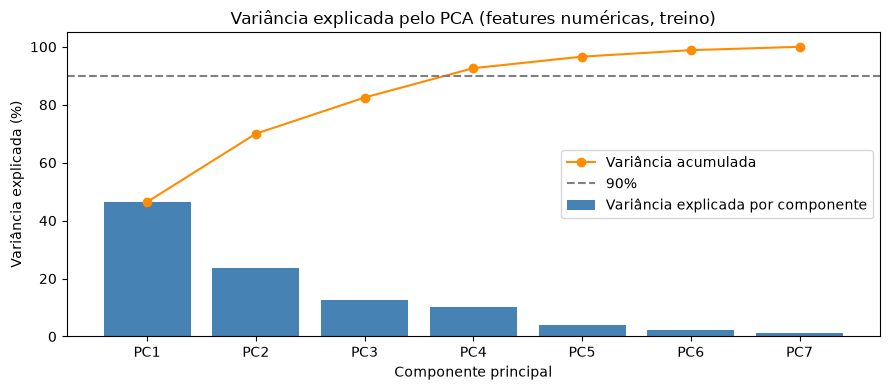

In [59]:
fig, ax = plt.subplots(figsize=(9, 4))
components = variance_table.index
ax.bar(components, variance_table["variância explicada (%)"], color="steelblue", label="Variância explicada por componente")
ax.plot(components, variance_table["variância acumulada (%)"], color="darkorange", marker="o", label="Variância acumulada")
ax.axhline(90, color="gray", linestyle="--", label="90%")
ax.set(title="Variância explicada pelo PCA (features numéricas, treino)", xlabel="Componente principal", ylabel="Variância explicada (%)")
ax.legend()
plt.tight_layout()
plt.show()

PC1 explica 46,43% da variância e PC2 23,57%, somando 70,00%. São necessários 3 componentes para passar de 80% (82,50%), 4 para passar de 90% (92,63%) e 5 para passar de 95% (96,60%). Os dois últimos componentes juntos explicam só 3,39%, o que é coerente com a correlação forte entre `engine_cc`, `max_power_bhp` e `torque_nm` vista na seção 9: parte da informação dessas variáveis é redundante. Se usarmos PCA na APS2, 4 ou 5 componentes preservariam mais de 90% da variância das numéricas, lembrando que variância explicada não é o mesmo que capacidade de prever o preço.

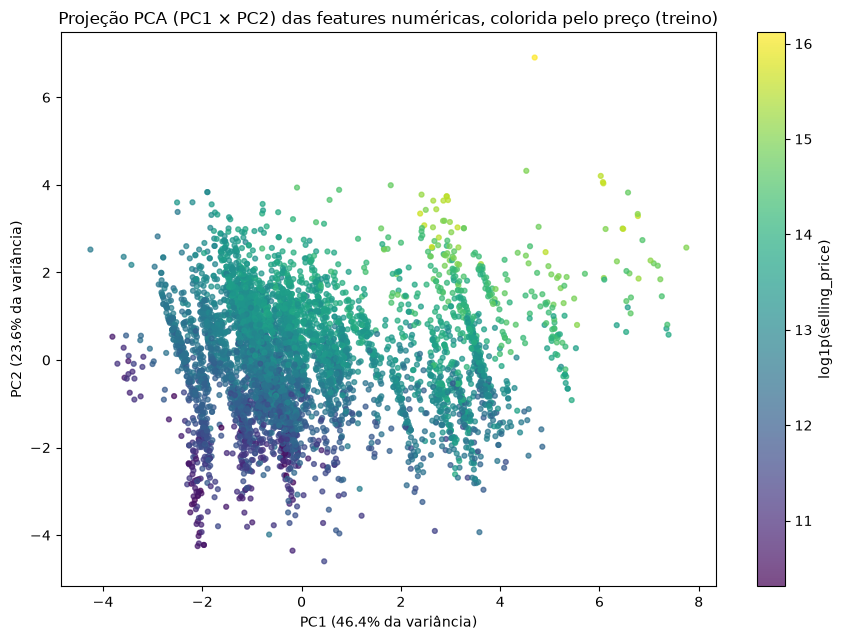

PC1 + PC2 explicam 70.0% da variância

Correlação de Spearman dos componentes com log1p(selling_price):
PC1    0.410
PC2    0.742
dtype: float64


In [60]:
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca = pca_2d.fit_transform(X_train_numeric)
pc1_var, pc2_var = pca_2d.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 6.5))
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=np.log1p(y_train), cmap="viridis", s=12, alpha=0.7)
fig.colorbar(scatter, ax=ax, label="log1p(selling_price)")
ax.set(
    title="Projeção PCA (PC1 × PC2) das features numéricas, colorida pelo preço (treino)",
    xlabel=f"PC1 ({pc1_var:.1f}% da variância)",
    ylabel=f"PC2 ({pc2_var:.1f}% da variância)",
)
plt.tight_layout()
plt.show()

print(f"PC1 + PC2 explicam {pc1_var + pc2_var:.1f}% da variância")
pc_scores = pd.DataFrame(X_train_pca, columns=["PC1", "PC2"], index=X_train.index)
print("\nCorrelação de Spearman dos componentes com log1p(selling_price):")
print(pc_scores.corrwith(np.log1p(y_train), method="spearman").round(3))

In [61]:
loadings = pd.DataFrame(pca_2d.components_.T, index=numeric_feature_names, columns=["PC1", "PC2"])
loadings.sort_values("PC1", key=abs, ascending=False).round(3)

,PC1,PC2
engine_cc,0.521,0.021
torque_nm,0.467,0.236
max_power_bhp,0.445,0.279
seats,0.381,-0.062
mileage_value,-0.372,0.291
km_driven,0.169,-0.549
year,-0.029,0.690


**Loadings:**
- **PC1** tem pesos positivos altos em `engine_cc` (0,521), `torque_nm` (0,467), `max_power_bhp` (0,445) e `seats` (0,381), e peso negativo em `mileage_value` (-0,372). Podemos ler PC1 como um eixo de "porte/motorização": carros maiores, mais potentes e que rodam menos km por unidade de combustível ficam à direita.
- **PC2** é dominado por `year` (0,690) e `km_driven` (-0,549), com contribuições menores de `mileage_value` (0,291) e `max_power_bhp` (0,279). É um eixo de "idade/uso": carros mais novos e menos rodados ficam em cima.

**Gráfico:** não aparecem grupos totalmente separados, mas a nuvem tem estrutura. Há uma grande concentração de pontos com PC1 entre ~-3 e ~1 (carros compactos, que são a maioria), um segundo grupo menos denso com PC1 entre ~2 e ~4 e pontos mais espalhados até ~8. As faixas diagonais dentro da nuvem provavelmente vêm dos valores discretos de `engine_cc`, `seats` e `year`, e não de grupos reais de veículos.

Existe um **gradiente de preço perceptível**: as cores escuras (preços baixos) ficam embaixo e à esquerda, e as mais claras (preços altos) no canto superior direito, ou seja, em carros de maior porte **e** mais novos. A correlação de Spearman com `log1p(selling_price)` confirma: 0,742 para PC2 e 0,410 para PC1. Assim, o eixo idade/uso está mais associado ao preço do que o eixo de porte, o que é coerente com `year` ter a maior correlação de Spearman.

Mesmo assim, a projeção 2D deixa de fora 30% da variância das numéricas e existe bastante mistura de cores em várias regiões, então esse gráfico é exploratório e não indica sozinho qual será o desempenho de um modelo.

## 16. Pipeline e ColumnTransformer

Juntando as decisões das seções anteriores em um único pré-processamento reutilizável.

In [62]:
preprocessor = ColumnTransformer([
    ("log_num", log_numeric_pipeline, log_numeric_features),
    ("num", numeric_pipeline, linear_numeric_features),
    ("cat", categorical_pipeline, categorical_features),
], verbose_feature_names_out=False)

preprocessing_pipeline = Pipeline([
    ("implausible_to_nan", implausible_to_nan),
    ("preprocessor", preprocessor),
])

X_train_prepared = preprocessing_pipeline.fit_transform(X_train)  # fit somente no treino
X_test_prepared = preprocessing_pipeline.transform(X_test)        # teste só é transformado

prepared_feature_names = preprocessing_pipeline.get_feature_names_out()

print(f"X_train original: {X_train.shape} -> preparado: {X_train_prepared.shape}")
print(f"X_test original:  {X_test.shape} -> preparado: {X_test_prepared.shape}")
print(f"NaN restantes em X_train_prepared: {np.isnan(X_train_prepared).sum()} | em X_test_prepared: {np.isnan(X_test_prepared).sum()}")

pd.DataFrame(X_train_prepared, columns=prepared_feature_names, index=X_train.index).head()

X_train original: (5540, 13) -> preparado: (5540, 53)
X_test original:  (1386, 13) -> preparado: (1386, 53)
NaN restantes em X_train_prepared: 0 | em X_test_prepared: 0


,km_driven,year,seats,engine_cc,max_power_bhp,mileage_value,torque_nm,fuel_CNG,fuel_Diesel,fuel_LPG,...,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Peugeot,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
4855,-1.047167,1.121745,-0.43702,0.135626,0.349533,0.898962,0.402508,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3143,1.364399,-0.830955,-0.43702,-0.371217,-0.188898,-0.022840,-0.136985,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4275,0.343282,-0.586867,-0.43702,-0.071166,0.067902,0.898962,0.578370,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2288,1.102039,-1.075042,-0.43702,-0.371217,-0.438154,-0.048446,0.222677,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3914,1.568857,-2.539567,-0.43702,0.125489,-0.183554,-1.635995,0.186711,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


O pipeline final foi ajustado somente com `X_train` e depois usado para transformar `X_train` e `X_test`:

- `implausible_to_nan`: `FunctionTransformer` com as regras fixas de valores impossíveis da seção 8;
- `preprocessor` (`ColumnTransformer`):
  - `log_num` → `km_driven`: `SimpleImputer(median)` → `log1p` → `StandardScaler`;
  - `num` → `year`, `seats`, `engine_cc`, `max_power_bhp`, `mileage_value`, `torque_nm`: `SimpleImputer(median)` → `StandardScaler`;
  - `cat` → `fuel`, `seller_type`, `transmission`, `owner`, `mileage_unit`, `brand`: `SimpleImputer(most_frequent)` → `OneHotEncoder(handle_unknown="ignore")`.

Resultado: as 13 colunas de entrada viraram **53 features** (7 numéricas + 46 colunas One-Hot), com shape (5540, 53) no treino e (1386, 53) no teste, e **nenhum NaN** restante nos dois conjuntos. O teste passou só por `transform`, usando medianas, modas, médias, desvios e categorias aprendidos no treino.

Nenhum modelo foi treinado. Na APS2 bastará acrescentar o estimador de regressão como último passo do pipeline, por exemplo `Pipeline([("implausible_to_nan", ...), ("preprocessor", preprocessor), ("model", regressor)])`, garantindo que todo o pré-processamento continue sendo ajustado apenas nos dados de treino, inclusive dentro da validação cruzada.

## 17. Verificação contra data leakage

- As 1202 duplicatas exatas foram removidas **antes** do train/test split, então não há linhas idênticas divididas entre treino e teste.
- As limpezas feitas antes do split (extração de números e unidades, conversão de torque, `brand`) são regras determinísticas aplicadas linha a linha, sem estatísticas do dataset.
- Toda a EDA aprofundada (target, univariadas, outliers, correlações, categóricas × target, numéricas × categóricas, missing e PCA) foi feita somente com `train_df` / `X_train`.
- As regras de valores impossíveis são limites fixos de domínio, definidos olhando apenas o treino, e aplicados da mesma forma a qualquer conjunto.
- O `SimpleImputer` (mediana e moda) foi ajustado somente no treino.
- O `StandardScaler` foi ajustado somente no treino.
- O `OneHotEncoder` foi ajustado somente no treino.
- O `PCA` foi ajustado somente nas features numéricas do treino.
- O conjunto de teste só foi usado em `preprocessing_pipeline.transform(X_test)`, para confirmar que o pipeline funciona; nenhum valor do teste foi usado em decisões de análise ou de pré-processamento.

## Principais conclusões da EDA

- **Estrutura do dataset:** 8128 linhas e 13 colunas originais. Após remover duplicatas ficaram 6926 linhas, divididas em 5540 para treino e 1386 para teste. O problema é de regressão, com target `selling_price`.
- **Target:** muito assimétrico (assimetria 5,48; média 521.486 × mediana 400.000 no treino), variando de 29.999 a 10.000.000. `log1p` reduz a assimetria para -0,13. Os preços mais altos correspondem a carros premium recentes e foram mantidos.
- **Duplicatas:** 1202 linhas exatamente iguais (algumas repetidas mais de 30 vezes) foram removidas antes do split para evitar vazamento entre treino e teste.
- **Features textuais:** `engine`, `max_power`, `mileage` e `torque` estavam como texto com unidades. `mileage` mistura `kmpl` (6631) e `km/kg` (87, só em CNG/LPG); `torque` mistura Nm (6227), kgm (480) e registros sem unidade (10), escritos de muitas formas diferentes.
- **Feature engineering:** criamos `engine_cc`, `max_power_bhp`, `mileage_value` + `mileage_unit`, `torque_nm` (kgm × 9,80665; 6686 conversões e 31 textos ambíguos ou inconsistentes como NaN) e `brand` (2058 nomes → 32 marcas).
- **Qualidade dos dados:** no treino encontramos valores impossíveis: 2 em `km_driven` (1.500.000 km e 1 km), 2 potências e 12 consumos iguais a zero e 3 torques de 789 Nm incompatíveis com o motor. Eles viram NaN por regras fixas incluídas no pipeline.
- **Missing values:** ~3% nas features técnicas (máximo de 3,65% em `torque_nm`), concentrados em 172 linhas do treino sem nenhuma ficha técnica.
- **Relações com o preço:** `year` tem a maior correlação de Spearman (0,705) e `max_power_bhp` a maior de Pearson (0,698), seguidas de `torque_nm` (0,644 / 0,622) e `engine_cc` (0,443 / 0,485). `km_driven` tem relação negativa fraca (-0,198 / -0,288). As relações ficam mais regulares com o preço em escala log.
- **Multicolinearidade:** `max_power_bhp`, `torque_nm` e `engine_cc` são fortemente correlacionadas entre si (até 0,86 de Pearson).
- **Outliers:** a regra do IQR sinaliza muitos pontos em `seats` (22,11%) e `engine_cc` (18,63%), mas são carros reais. Mantivemos os extremos plausíveis e aplicamos `log1p` em `km_driven`.
- **Diferenças entre categorias:** automáticos têm mediana de preço ~2,3 vezes maior que manuais; Diesel tem a maior mediana entre os combustíveis (520.000); e o preço mediano cai com o número de donos (509.999 → 185.000). Essas diferenças se misturam com outras variáveis: automáticos são mais potentes (126,66 × 80,00 bhp) e carros com mais donos são mais antigos (mediana de 2016 → 2008). Categorias raras: CNG, LPG, `Test Drive Car`, `Trustmark Dealer` e várias marcas.
- **PCA:** PC1 (46,43%) representa porte/motorização e PC2 (23,57%) idade/uso, somando 70%; 4 componentes explicam 92,63%. Não há grupos isolados, mas existe um gradiente de preço, principalmente ao longo de PC2 (Spearman 0,742 com `log1p(selling_price)`).
- **Imputação, encoding e scaling:** mediana nas numéricas, moda nas categóricas, `log1p` em `km_driven`, `StandardScaler` nas numéricas e `OneHotEncoder(handle_unknown="ignore")` nas categóricas.
- **Pipeline final:** `FunctionTransformer` de valores impossíveis + `ColumnTransformer` com três ramos (`log_num`, `num`, `cat`), ajustado só no treino, gerando 53 features sem NaN para treino e teste.
- **Limitações:** não há identificador de anúncio (não sabemos com certeza se as duplicatas são o mesmo anúncio); `mileage_value` mistura unidades diferentes; 31 textos de torque ambíguos viraram NaN e alguns erros de digitação podem continuar escondidos em valores plausíveis; os limites de valores impossíveis são escolhas de domínio; categorias raras têm estatísticas instáveis; `brand` ignora diferenças entre modelos da mesma marca; os preços não têm data do anúncio para ajuste por inflação; e as correlações observadas não indicam causalidade.

## Próximos passos

Na APS2 vamos testar modelos de regressão para prever `selling_price` usando o `preprocessing_pipeline` construído nesta etapa, bastando conectar o estimador após o pré-processamento. Pontos que já deixamos anotados:
- avaliar o uso de `log1p(selling_price)` como target, dada a forte assimetria;
- usar validação cruzada somente no treino e manter o teste para a avaliação final;
- considerar a multicolinearidade entre `engine_cc`, `max_power_bhp` e `torque_nm`, e se vale a pena usar PCA;
- escolher métricas de regressão adequadas para comparar os modelos.

Nesta APS nenhum modelo foi escolhido ou treinado.

## Referências

- Vehicle Dataset from CarDekho (nehalbirla). Kaggle. https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho
- Scikit-learn. `Pipeline`. https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
- Scikit-learn. `ColumnTransformer`. https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html
- Scikit-learn. `SimpleImputer`. https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html
- Scikit-learn. `OneHotEncoder`. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
- Scikit-learn. `StandardScaler`. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- Scikit-learn. `PCA`. https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
- Scikit-learn. `FunctionTransformer`. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.FunctionTransformer.html
- Scikit-learn. `train_test_split`. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- Pandas documentation. https://pandas.pydata.org/docs/
- NIST Special Publication 811, *Guide for the Use of the International System of Units (SI)* — fator de conversão 1 kgf·m = 9,80665 N·m. https://www.nist.gov/pml/special-publication-811